In [21]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
#%load_ext line_profiler
#%load_ext snakeviz
%autoreload 2

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import corner

import pickle

import enterprise
from enterprise.pulsar import Pulsar
import enterprise.signals.parameter as parameter
from enterprise.signals import utils
from enterprise.signals import signal_base
from enterprise.signals import selections
from enterprise.signals.selections import Selection
from enterprise.signals import white_signals
from enterprise.signals import gp_signals
from enterprise.signals import deterministic_signals
import enterprise.constants as const

from enterprise_extensions import deterministic

from scipy.stats import norm

import libstempo as T2
import libstempo.toasim as LT
import libstempo.plot as LP

import glob
import json
import h5py
import healpy as hp
import scipy.constants as sc
import emcee

from numba.typed import List

import sys
import h5py

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
target_d_L = 75.4#Mpc

In [3]:
base = "IPTA_MDC2_G2D2_detection_"
crnr_plt_title1 =base+'corner plot_old'
crnr_plt_title2 =base
trace_plot_title = base+'trace_plot'
BF_histogram_title = base+'log10A_histogram'
BFerr_title = base+'log10A_histogram_error'

In [4]:
pwd

'/scratch/na00078/projects/IPTA_MDC2/post_processing'

## Generate Outfile

## Run Outfile

In [5]:
#COMMENT IF OUTFILE GENERATED
#Thinning script for one source
i = "/scratch/na00078/projects/IPTA_MDC2/h5_files/dl_masked/G2D2_narrow_detect_outfile.h5"
infile = i
first_n_param = 8
# outfile = '/scratch/na00078/QuickCW_targeted_runs/results/3C66B_outfile.h5'

print(infile)
print(first_n_param)

with h5py.File(infile, 'r') as f:
    Ts = f['T-ladder'][...]
    samples_cold = f['samples_cold'][:,:,:first_n_param]
    print(samples_cold[-1].shape)
    log_likelihood = f['log_likelihood'][:1,:]
    print(log_likelihood.shape)
    par_names = [x.decode('UTF-8') for x in list(f['par_names'])]
    acc_fraction = f['acc_fraction'][...]
    fisher_diag = f['fisher_diag'][...]

/scratch/na00078/projects/IPTA_MDC2/h5_files/G2D2_narrow_detect_outfile.h5
8
(100000000, 8)
(1, 100000000)


## Corner Plots

In [6]:
KPC2S = sc.parsec / sc.c * 1e3
SOLAR2S = sc.G / sc.c ** 3 * 1.98855e30


xxx0 = {"0_cos_gwtheta":np.cos(0.6387905062299246),
       "0_cos_inc":0.8412486994612669,
       "0_gwphi":3.3335788713091694,
       "0_log10_fgw":np.log10(3.7e-09),
       "0_log10_h":-13.668773493298787,
       "0_log10_mc":np.log10(4300000000),
       "phase0": 0.24434609527920614,
        "psi": 1.1187560505283651,
        "distance": 75.4,}


xxx = {
       "0_cos_inc":0.8412486994612669,
        "0_log10_h":-13.668773493298787,
       "0_log10_mc":np.log10(4300000000),
       "phase0": 0.24434609527920614,
        "psi": 1.1187560505283651}

xxx['gwb_gamma'] = np.nan    
xxx['gwb_log10_A'] = -15.070581074285707
    
#print(xxx)

# In[6]:




Masked samples: (126372, 5)
Unmasked samples (thinned): (1000000, 5)


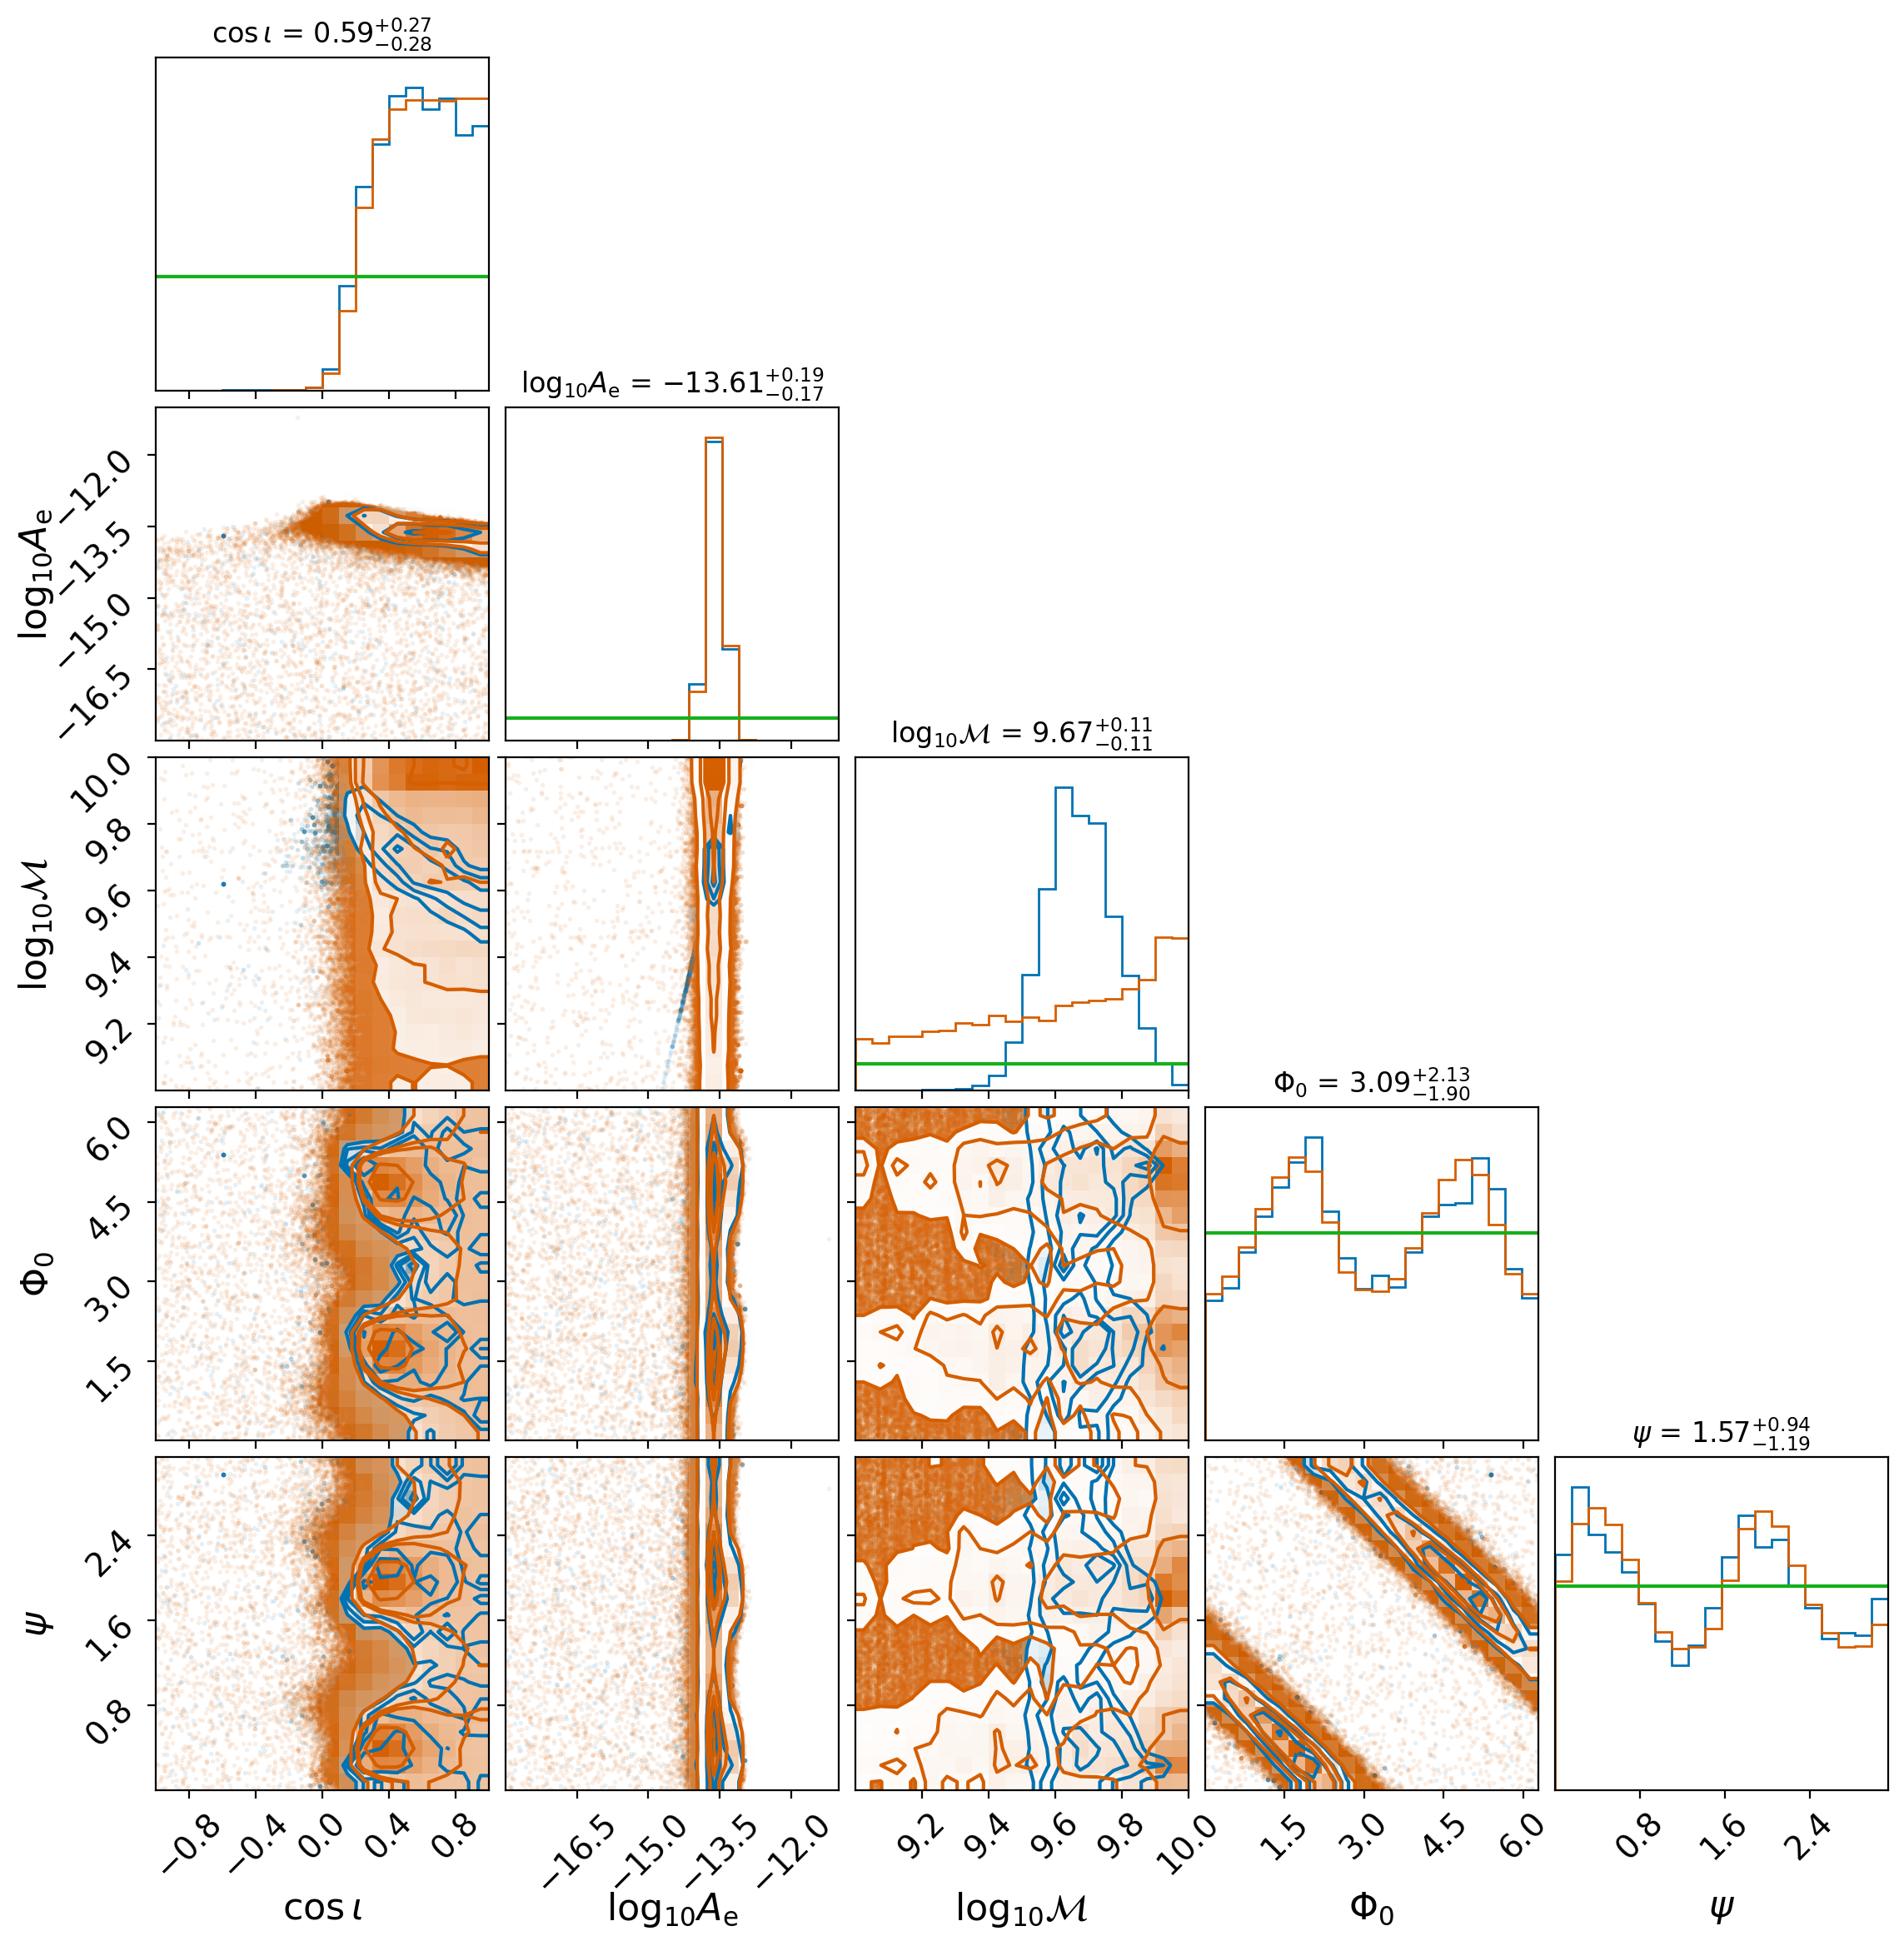

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import corner

# -------------------------------------------------------------------
# 1. Setup labels & truth mapping
# -------------------------------------------------------------------
corner_mask = [0, 1, 2, 3, 4, 5, 6, 7]
par_keys = ["0_cos_gwtheta", "0_cos_inc", "0_gwphi", "0_log10_fgw",
            "0_log10_h", "0_log10_mc", "0_phase0", "0_psi", "log10_d_L"]

labels = [
    r"$\cos \iota$",
    r"$\log_{10} A_{\rm e}$",
    r"$\log_{10} {\cal M}$",
    r"$\Phi_0$",
    r"$\psi$"
]

label_to_key = {
    r"$\cos \iota$": "0_cos_inc",
    r"$\log_{10} A_{\rm e}$": "0_log10_h",
    r"$\log_{10} {\cal M}$": "0_log10_mc",
    r"$\Phi_0$": "phase0",
    r"$\psi$": "psi"
}


# -------------------------------------------------------------------
# 2. Burnin / thinning for masked samples
# -------------------------------------------------------------------
burnin = 0
thin = 1   # masked samples: keep your original thin

unmasked_thin = 100     # << REQUIRED >>

ranges = [(-1,1), (-18,-11), (9,10), (0,2*np.pi), (0,np.pi)]

# -------------------------------------------------------------------
# 3. Compute luminosity distance
# -------------------------------------------------------------------
megaparsec = 3.086e+22
speed_of_light = 299792458.0
T_sun = 1.327124400e20 / speed_of_light**3

h_amp = 10**samples_cold[0][burnin::thin,4]
fff   = 10**samples_cold[0][burnin::thin,3]
mmm   = 10**samples_cold[0][burnin::thin,5]

log10_d_L = np.log10(
    2 * (mmm * T_sun)**(5/3) * (np.pi * fff)**(2/3) / h_amp * speed_of_light / megaparsec
)

# -------------------------------------------------------------------
# 4. Generate masks
# -------------------------------------------------------------------
d_L_percent_tolerance = 1.0
d_L_min = target_d_L*(1 - d_L_percent_tolerance/100)
d_L_max = target_d_L*(1 + d_L_percent_tolerance/100)

d_L_mask = np.where((10**log10_d_L >= d_L_min) & (10**log10_d_L <= d_L_max))[0]

# -------------------------------------------------------------------
# 5. Create sample matrices
# -------------------------------------------------------------------
samples2plot = np.concatenate(
    (samples_cold[0][burnin::thin, corner_mask],
     np.array([log10_d_L]).T),
    axis=1
)

# masked samples
samples2plot_masked = np.vstack((
    samples2plot[d_L_mask,1],
    samples2plot[d_L_mask,4],
    samples2plot[d_L_mask,5],
    samples2plot[d_L_mask,6],
    samples2plot[d_L_mask,7]
)).T


samples2plot_unmasked = np.vstack((
    samples_cold[0][burnin::unmasked_thin, 1],
    samples_cold[0][burnin::unmasked_thin, 4],
    samples_cold[0][burnin::unmasked_thin, 5],
    samples_cold[0][burnin::unmasked_thin, 6],
    samples_cold[0][burnin::unmasked_thin, 7]
)).T

print("Masked samples:", samples2plot_masked.shape)
print("Unmasked samples (thinned):", samples2plot_unmasked.shape)

# -------------------------------------------------------------------
# 6. Colorblind-safe palette (Okabe–Ito)
# -------------------------------------------------------------------
c_masked   = "#0072B2"      # blue
c_unmasked = "#D55E00"      # vermillion


# -------------------------------------------------------------------
# 7. First (masked) corner plot
# -------------------------------------------------------------------
fig = corner.corner(
    samples2plot_masked,
    labels=labels,
    show_titles=True,
    range=ranges,
    color=c_masked,
    hist_kwargs={"density": True, "color": c_masked},
    contour_kwargs={"colors": [c_masked]},
    label_kwargs={"fontsize": 16},
)

# -------------------------------------------------------------------
# 8. Overplot unmasked samples (thinned)
# -------------------------------------------------------------------
corner.corner(
    samples2plot_unmasked,
    fig=fig,
    labels=labels,
    show_titles=False,
    range=ranges,
    color=c_unmasked,
    hist_kwargs={"density": True, "color": c_unmasked},
    contour_kwargs={"colors": [c_unmasked]},
)

# -------------------------------------------------------------------
# 9. Formatting
# -------------------------------------------------------------------
for ax in fig.get_axes():
    ax.tick_params(axis="both", labelsize=14)
    ax.xaxis.label.set_size(16)
    ax.yaxis.label.set_size(16)

# -------------------------------------------------------------------
# 10. Priors on 1D diagonals (unchanged)
# -------------------------------------------------------------------
for i, ax in enumerate(fig.axes):

    if i == 0:   # cos i
        Xs = np.linspace(-1,1)
        ax.plot(Xs, Xs*0 + 1/2, color="xkcd:green")

    elif i == (len(labels)+1):   # log10 A
        Xs = np.linspace(-18,-11)
        ax.plot(Xs, Xs*0 + 1/7, color="xkcd:green")

    elif i == 2*(len(labels)+1):   # log10 Mc
        Xs = np.linspace(
            np.min(samples2plot[d_L_mask,5]),
            np.max(samples2plot[d_L_mask,5]))
        ax.plot(Xs, Xs*0 + 1/3, color="xkcd:green")

    elif i == 3*(len(labels)+1):   # phi0
        Xs = np.linspace(0,2*np.pi)
        ax.plot(Xs, Xs*0 + 1/(2*np.pi), color="xkcd:green")

    elif i == 4*(len(labels)+1):   # psi
        Xs = np.linspace(0,np.pi)
        ax.plot(Xs, Xs*0 + 1/np.pi, color="xkcd:green")

# -------------------------------------------------------------------
# 11. Title
# -------------------------------------------------------------------
#fig.suptitle(crnr_plt_title1, fontsize=25, y=1.05)
plt.show()


Masked samples: (126372, 5)
Unmasked samples (thinned): (998737, 5)


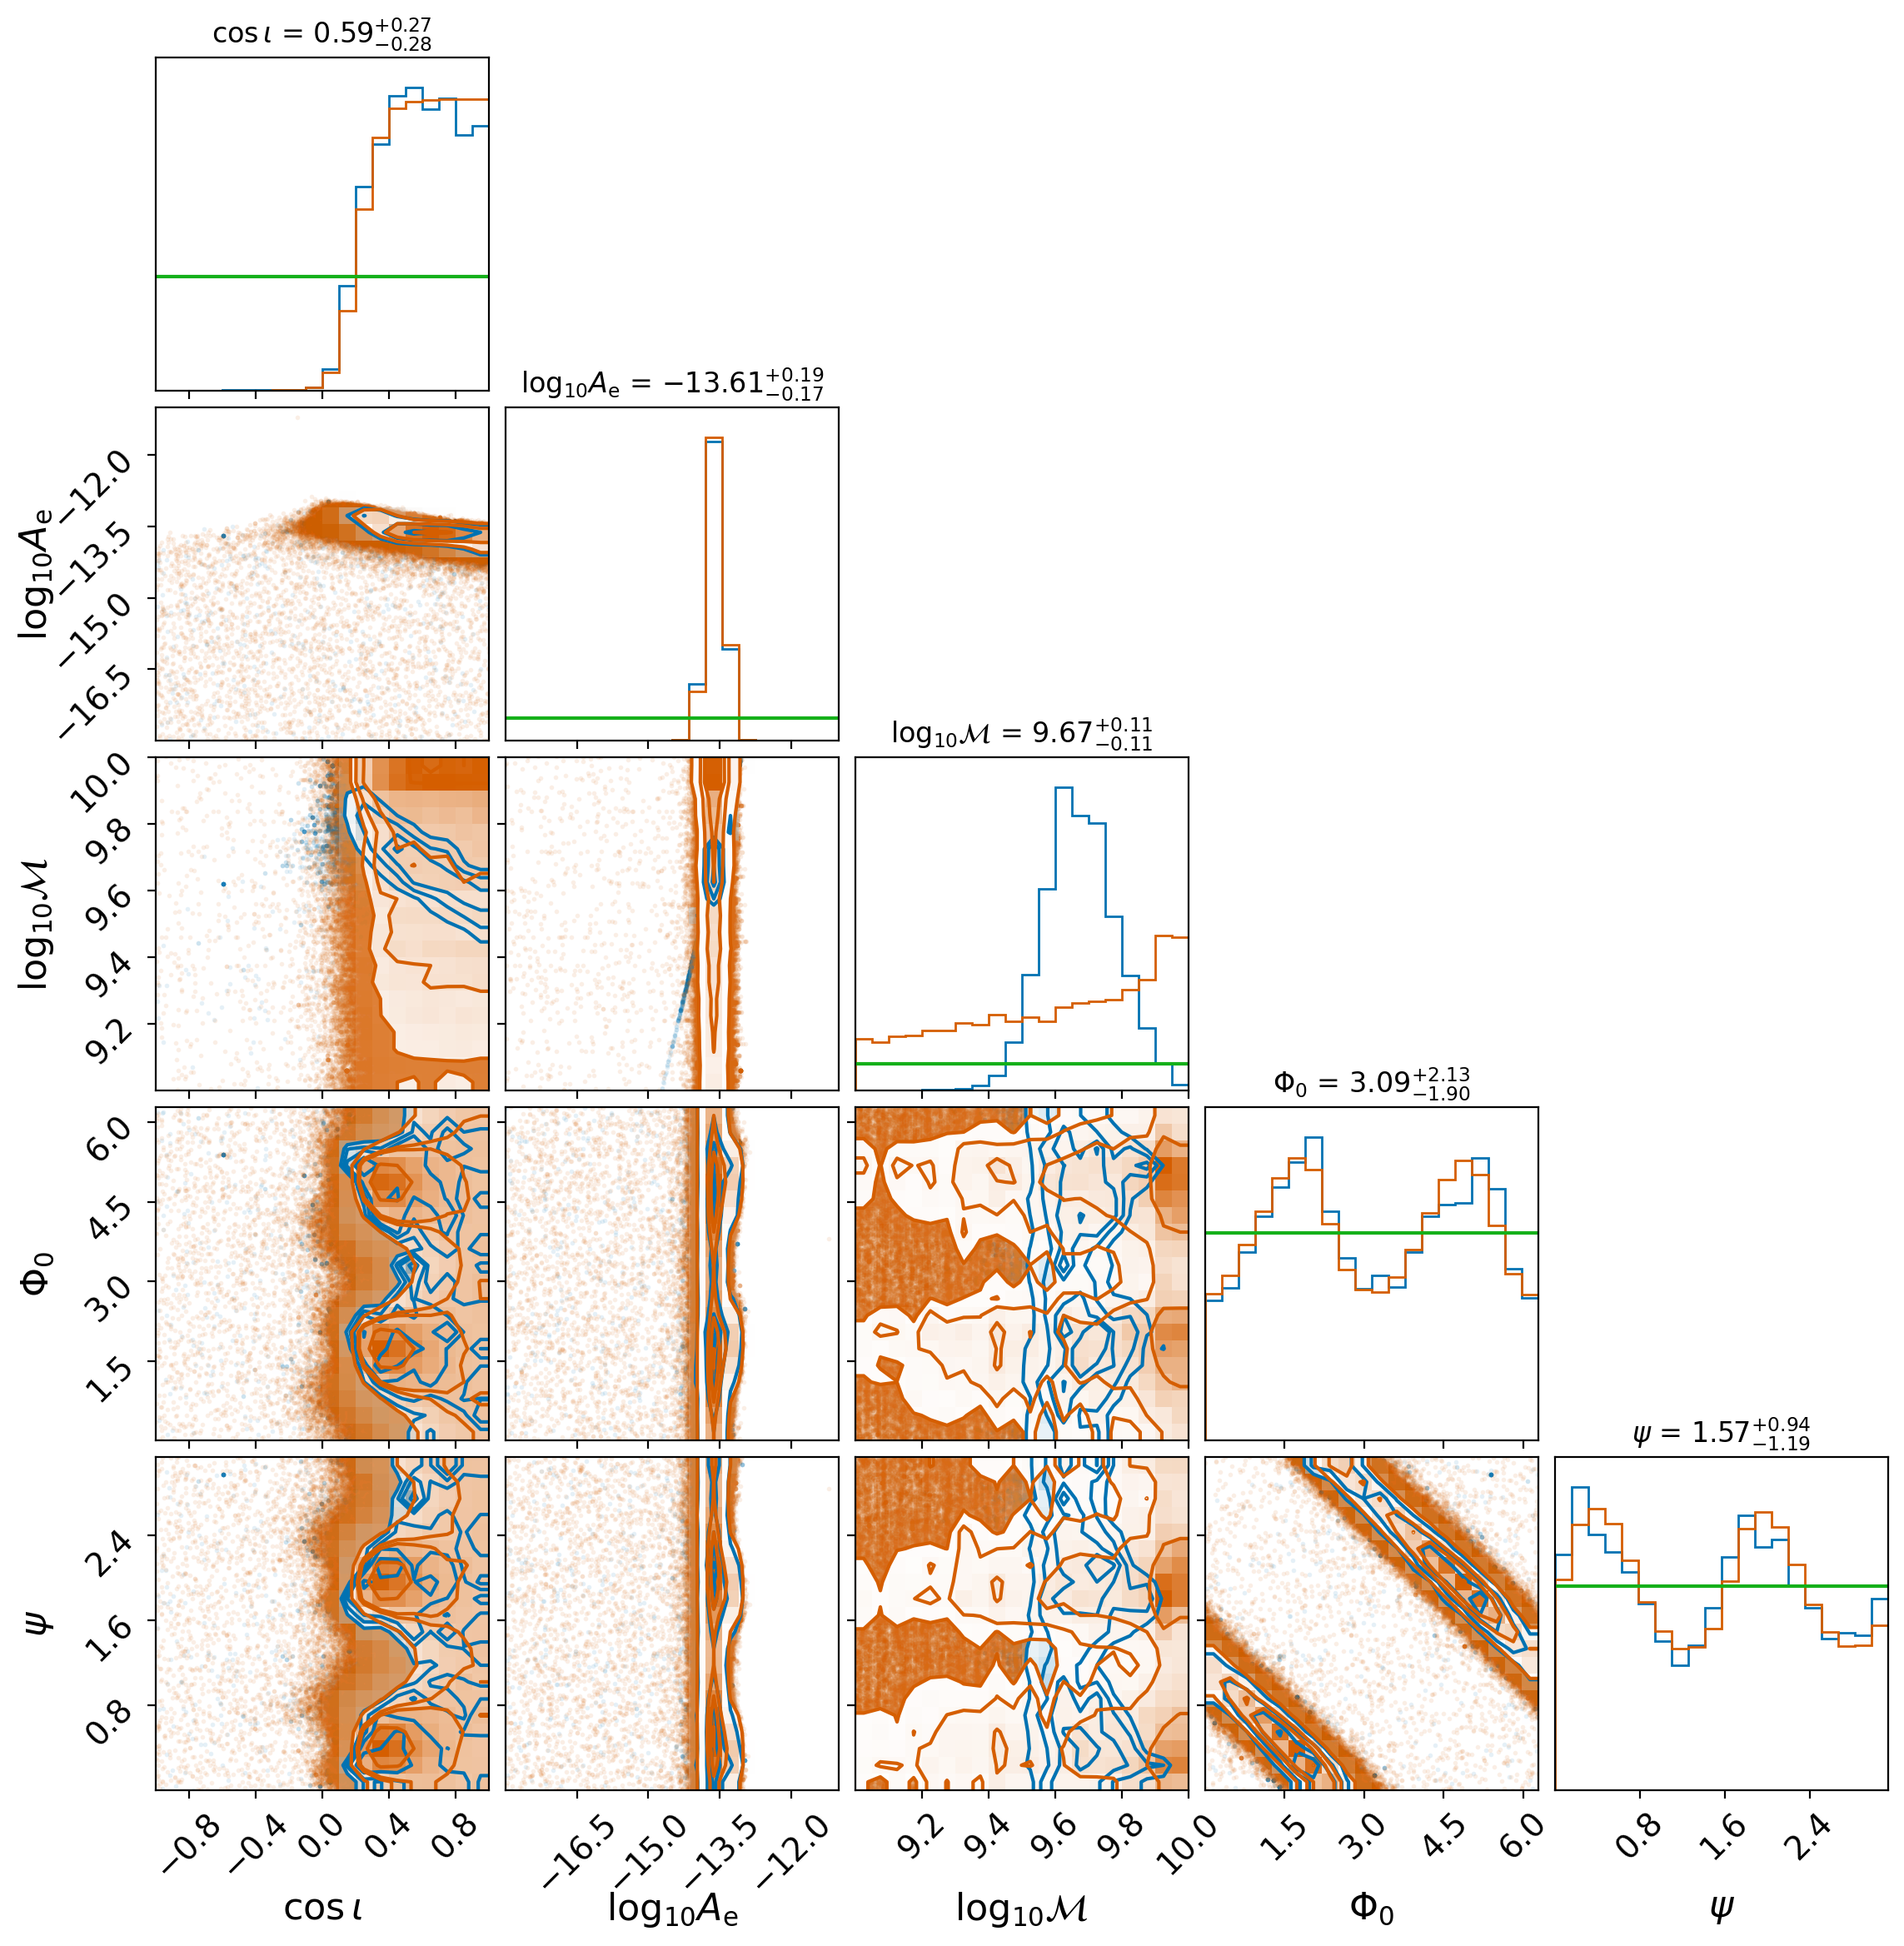

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import corner

# -------------------------------------------------------------------
# 1. Setup labels & truth mapping
# -------------------------------------------------------------------
corner_mask = [0, 1, 2, 3, 4, 5, 6, 7]
par_keys = ["0_cos_gwtheta", "0_cos_inc", "0_gwphi", "0_log10_fgw",
            "0_log10_h", "0_log10_mc", "0_phase0", "0_psi", "log10_d_L"]

labels = [
    r"$\cos \iota$",
    r"$\log_{10} A_{\rm e}$",
    r"$\log_{10} {\cal M}$",
    r"$\Phi_0$",
    r"$\psi$"
]

label_to_key = {
    r"$\cos \iota$": "0_cos_inc",
    r"$\log_{10} A_{\rm e}$": "0_log10_h",
    r"$\log_{10} {\cal M}$": "0_log10_mc",
    r"$\Phi_0$": "phase0",
    r"$\psi$": "psi"
}


# -------------------------------------------------------------------
# 2. Burnin / thinning for masked samples
# -------------------------------------------------------------------
burnin = 0
thin = 1   # masked samples: keep your original thin

unmasked_thin = 100     # << REQUIRED >>

ranges = [(-1,1), (-18,-11), (9,10), (0,2*np.pi), (0,np.pi)]

# -------------------------------------------------------------------
# 3. Compute luminosity distance
# -------------------------------------------------------------------
megaparsec = 3.086e+22
speed_of_light = 299792458.0
T_sun = 1.327124400e20 / speed_of_light**3

h_amp = 10**samples_cold[0][burnin::thin,4]
fff   = 10**samples_cold[0][burnin::thin,3]
mmm   = 10**samples_cold[0][burnin::thin,5]

log10_d_L = np.log10(
    2 * (mmm * T_sun)**(5/3) * (np.pi * fff)**(2/3) / h_amp * speed_of_light / megaparsec
)

# -------------------------------------------------------------------
# 4. Generate masks
# -------------------------------------------------------------------
d_L_percent_tolerance = 1.0
d_L_min = target_d_L*(1 - d_L_percent_tolerance/100)
d_L_max = target_d_L*(1 + d_L_percent_tolerance/100)

d_L_mask = np.where((10**log10_d_L >= d_L_min) & (10**log10_d_L <= d_L_max))[0]
not_d_L_mask_1 = np.where(10**log10_d_L < d_L_min)[0]
not_d_L_mask_2 = np.where(10**log10_d_L > d_L_max)[0]
merged_non_dL = np.concatenate((not_d_L_mask_1, not_d_L_mask_2))

# -------------------------------------------------------------------
# 5. Create sample matrices
# -------------------------------------------------------------------
samples2plot = np.concatenate(
    (samples_cold[0][burnin::thin, corner_mask],
     np.array([log10_d_L]).T),
    axis=1
)

# masked samples
samples2plot_masked = np.vstack((
    samples2plot[d_L_mask,1],
    samples2plot[d_L_mask,4],
    samples2plot[d_L_mask,5],
    samples2plot[d_L_mask,6],
    samples2plot[d_L_mask,7]
)).T

# unmasked samples with thinning 1000 applied **after masking**
thin_idx = merged_non_dL[::unmasked_thin]

samples2plot_unmasked = np.vstack((
    samples2plot[thin_idx,1],
    samples2plot[thin_idx,4],
    samples2plot[thin_idx,5],
    samples2plot[thin_idx,6],
    samples2plot[thin_idx,7]
)).T

print("Masked samples:", samples2plot_masked.shape)
print("Unmasked samples (thinned):", samples2plot_unmasked.shape)

# -------------------------------------------------------------------
# 6. Colorblind-safe palette (Okabe–Ito)
# -------------------------------------------------------------------
c_masked   = "#0072B2"      # blue
c_unmasked = "#D55E00"      # vermillion


# -------------------------------------------------------------------
# 7. First (masked) corner plot
# -------------------------------------------------------------------
fig = corner.corner(
    samples2plot_masked,
    labels=labels,
    show_titles=True,
    range=ranges,
    color=c_masked,
    hist_kwargs={"density": True, "color": c_masked},
    contour_kwargs={"colors": [c_masked]},
    label_kwargs={"fontsize": 16},
)

# -------------------------------------------------------------------
# 8. Overplot unmasked samples (thinned)
# -------------------------------------------------------------------
corner.corner(
    samples2plot_unmasked,
    fig=fig,
    labels=labels,
    show_titles=False,
    range=ranges,
    color=c_unmasked,
    hist_kwargs={"density": True, "color": c_unmasked},
    contour_kwargs={"colors": [c_unmasked]},
)

# -------------------------------------------------------------------
# 9. Formatting
# -------------------------------------------------------------------
for ax in fig.get_axes():
    ax.tick_params(axis="both", labelsize=14)
    ax.xaxis.label.set_size(16)
    ax.yaxis.label.set_size(16)

# -------------------------------------------------------------------
# 10. Priors on 1D diagonals (unchanged)
# -------------------------------------------------------------------
for i, ax in enumerate(fig.axes):

    if i == 0:   # cos i
        Xs = np.linspace(-1,1)
        ax.plot(Xs, Xs*0 + 1/2, color="xkcd:green")

    elif i == (len(labels)+1):   # log10 A
        Xs = np.linspace(-18,-11)
        ax.plot(Xs, Xs*0 + 1/7, color="xkcd:green")

    elif i == 2*(len(labels)+1):   # log10 Mc
        Xs = np.linspace(
            np.min(samples2plot[d_L_mask,5]),
            np.max(samples2plot[d_L_mask,5]))
        ax.plot(Xs, Xs*0 + 1/3, color="xkcd:green")

    elif i == 3*(len(labels)+1):   # phi0
        Xs = np.linspace(0,2*np.pi)
        ax.plot(Xs, Xs*0 + 1/(2*np.pi), color="xkcd:green")

    elif i == 4*(len(labels)+1):   # psi
        Xs = np.linspace(0,np.pi)
        ax.plot(Xs, Xs*0 + 1/np.pi, color="xkcd:green")

# -------------------------------------------------------------------
# 11. Title
# -------------------------------------------------------------------
#fig.suptitle(crnr_plt_title1, fontsize=25, y=1.05)
plt.show()


hamp [6.2618183e-12 8.7369629e-18 9.8359422e-15 ... 2.9562832e-14 2.9562832e-14
 2.9562832e-14]
freq [3.7000025e-09 3.7000025e-09 3.7000025e-09 ... 3.7000025e-09 3.7000025e-09
 3.7000025e-09]
mc [1.1089887e+07 4.0102052e+10 1.1089887e+07 ... 2.9482121e+10 2.9482121e+10
 2.9482121e+10]
Length of logdL 100000000
required values 8.484214e+00 3.7000025e-09 108456936.0 3.9389356e-14
dL min 74.646
dL max 76.15400000000001
10**log10_d_L [1.2520342e-05 7.6446065e+06 7.9707820e-03 ... 1.3529763e+03 1.3529763e+03
 1.3529763e+03]
min 10**log10_d_L 1.2520342e-05
max 10**log10_d_L 304939620.0
d_L_mask [   26110    26111    26112 ... 99849743 99957396 99957397]
notd_L_mask1 [       0        2        3 ... 99999825 99999834 99999862]
notd_L_mask2 [       1        4        5 ... 99999997 99999998 99999999]
merged_non_dL [       0        2        3 ... 99999997 99999998 99999999]
Sample shape (100000000, 9)
dL_mask length 126372
5
Max Mc sampled 10.04807


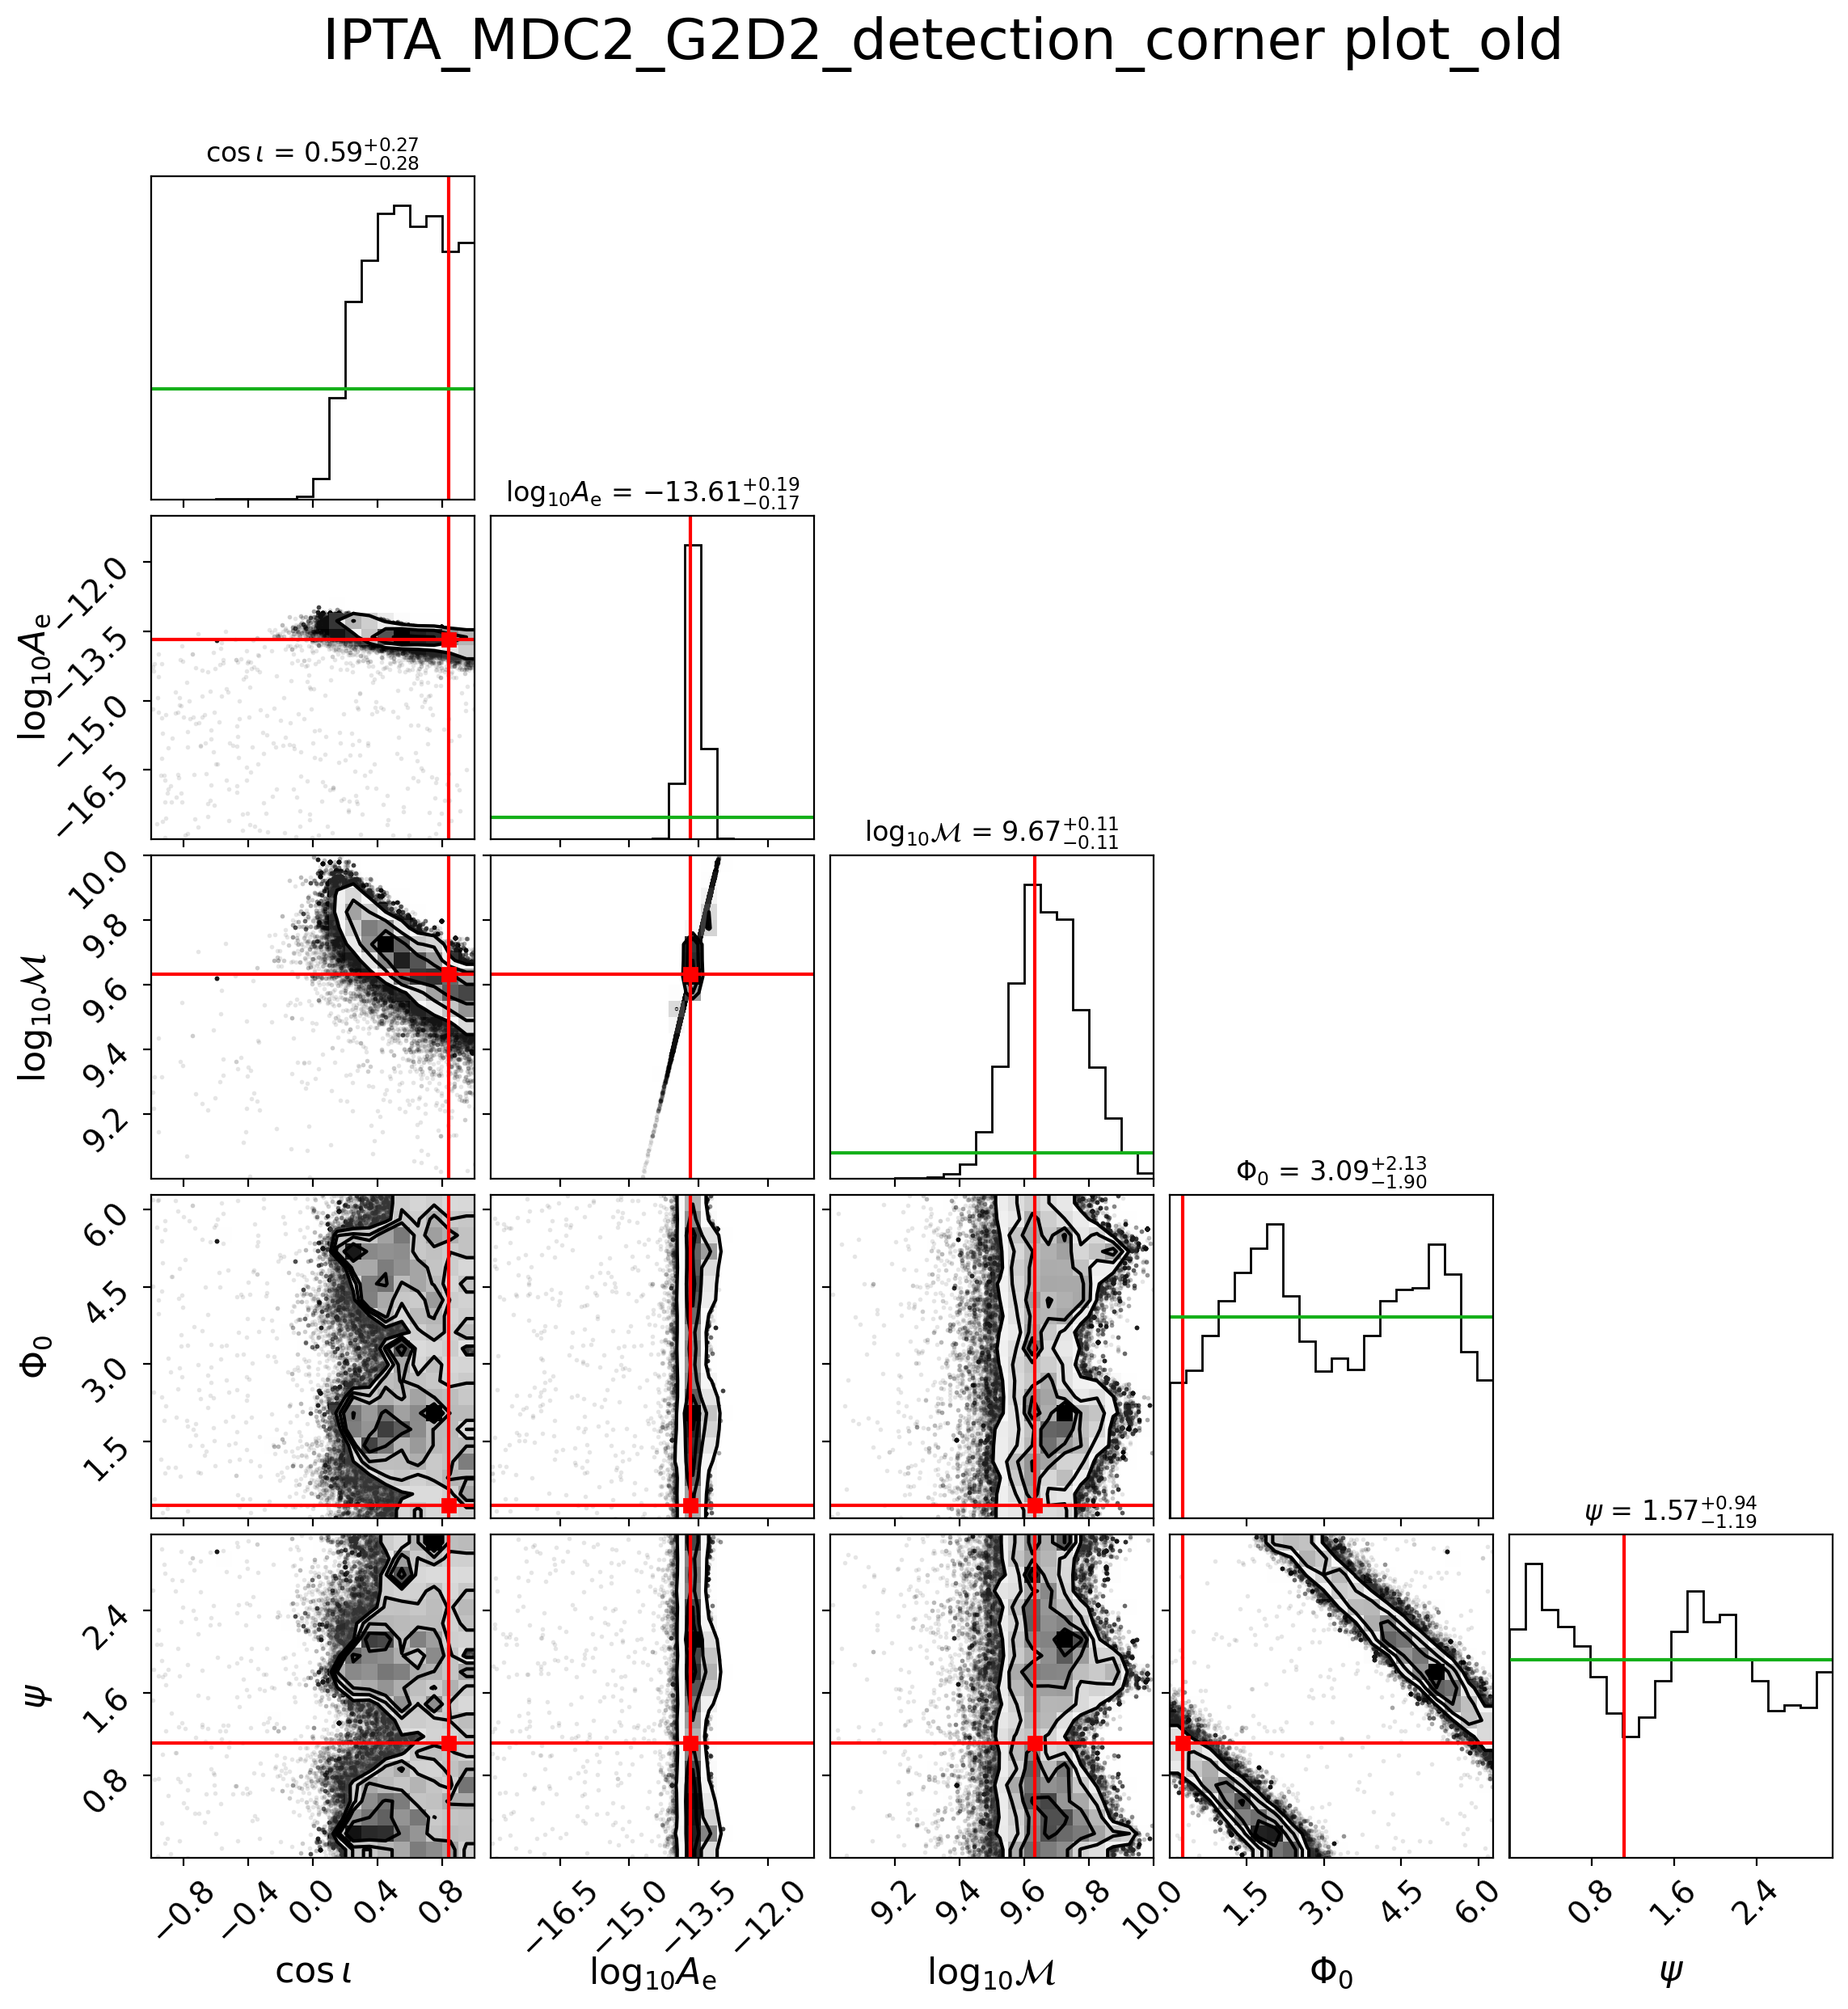

In [8]:
#corner plot of parameters common to all pulsars (Contains Luminosity distance)
corner_mask = [0, 1, 2, 3, 4, 5, 6, 7]
par_keys = ["0_cos_gwtheta", "0_cos_inc", "0_gwphi", "0_log10_fgw",
          "0_log10_h", "0_log10_mc", "0_phase0", "0_psi","log10_d_L"]
#labels = [r"$\cos \theta$", r"$\cos \iota$", r"$\phi$", r"$\log_{10} f_{\rm GW}$",
      #    r"$\log_{10} A_{\rm e}$", r"$\log_{10} {\cal M}$", r"$\Phi_0$", r"$\psi$",r"$\log_{10} d_L$"]
labels = [r"$\cos \iota$", r"$\log_{10} A_{\rm e}$", r"$\log_{10} {\cal M}$", r"$\Phi_0$",r"$\psi$"]

label_to_key = {
    r"$\cos \iota$": "0_cos_inc",
    r"$\log_{10} A_{\rm e}$": "0_log10_h",
    r"$\log_{10} {\cal M}$": "0_log10_mc",
    r"$\Phi_0$": "phase0",
    r"$\psi$": "psi"
}

# Now build the truths array by translating labels
truths = [xxx[label_to_key[l]] for l in labels]


#set burnin and thinning
#burnin = 0
#burnin = 500_000
burnin = 0#int(1e6)
thin = 1

#set ranges
ranges = [(-1,1), (-18,-11), (9,10), (0,2*np.pi), (0,np.pi)]
#ranges = [(-1,1), (-1,1), (0,2*np.pi), (-8.704,np.log10(3e-7)), (-18,-11), (6.6,12), (0,2*np.pi), (0,np.pi), (0,10)]
#ranges = [0.99]*9


megaparsec = 3.086e+22 #meter
speed_of_light = 299792458.0 #m/s
T_sun = 1.327124400e20 / speed_of_light**3 #G*M_sun/c^3 = R_sun/c-->Sun time

############################################################################
h_amp = 10**samples_cold[0][burnin::thin,4]
fff = 10**samples_cold[0][burnin::thin,3]
mmm = 10**samples_cold[0][burnin::thin,5]

print('hamp',h_amp)
print('freq',fff)
print('mc',mmm)

log10_d_L = np.log10(2 * (mmm*T_sun)**(5/3) * (np.pi*fff)**(2/3) / h_amp *speed_of_light/megaparsec)
print("Length of logdL", len(log10_d_L))
print("required values",np.max(log10_d_L), fff[1000], mmm[1000], h_amp[1000] )
#####################################

d_L_percent_tolerance = 1.0
#####################################

d_L_min = target_d_L*(1-d_L_percent_tolerance/100)
d_L_max = target_d_L*(1+d_L_percent_tolerance/100)
print("dL min",d_L_min)
print("dL max",d_L_max)
print("10**log10_d_L",10**log10_d_L)
print("min 10**log10_d_L",np.min(10**log10_d_L))
print("max 10**log10_d_L",np.max(10**log10_d_L))

d_L_mask = np.where((10**log10_d_L>=d_L_min) & (10**log10_d_L<=d_L_max))[0]
print("d_L_mask",d_L_mask)

#########################
not_d_L_mask_1 = np.where((10**log10_d_L<d_L_min))[0] #& (10**log10_d_L>d_L_max))[0]
print("notd_L_mask1",not_d_L_mask_1)
not_d_L_mask_2 = np.where((10**log10_d_L>d_L_max))[0] #& ())[0]
print("notd_L_mask2",not_d_L_mask_2)

merged_non_dL = np.concatenate((not_d_L_mask_1,not_d_L_mask_2))
print("merged_non_dL",merged_non_dL)
########################################

samples2plot = np.concatenate((samples_cold[0][burnin::thin,corner_mask], np.array([log10_d_L,]).T), axis=1)

print("Sample shape", samples2plot.shape)
print("dL_mask length", len(d_L_mask))
print(len(ranges))

print("Max Mc sampled", np.max(samples2plot[d_L_mask,5]))

samples2plot_detect = np.vstack((
                          samples2plot[d_L_mask,1],
                          samples2plot[d_L_mask,4],
                          samples2plot[d_L_mask,5],
                          samples2plot[d_L_mask,6],
                          samples2plot[d_L_mask,7])).T


#fig = corner.corner(samples2plot_detect,
  #                  labels=labels,
   #                 show_titles=True, quantiles=[0.16, 0.5, 0.84],
    #                range=ranges, hist_kwargs={"density":True})
    
fig = corner.corner(
    samples2plot_detect,
    labels=labels,
    show_titles=True,
    range=ranges,
    hist_kwargs={"density": True},
    truths=truths,
    truth_color="red"   # optional, highlights them in red
)

for ax in fig.get_axes():
    ax.tick_params(axis="both", labelsize=14)   # tick labels
    ax.xaxis.label.set_size(16)                 # x-axis label
    ax.yaxis.label.set_size(16)                 # y-axis label

#plot priors over 1D posteriors
for i, ax in enumerate(fig.axes):
    if i==0:#(len(labels)+1): #cos inc and cos theta
        Xs = np.linspace(-1,1)
        ax.plot(Xs, Xs*0+1/2, color="xkcd:green")
    #elif i==3*(len(labels)+1): #log10_fgw
     #   Xs = np.linspace(np.log10(3.5e-9), -7.0)
        # Y = plot_Gaussian(Xs,np.log10(1.13e-8),1)
        # ax.plot(Xs,Y, color='xkcd:green')
      #  ax.plot(Xs, Xs*0+1/(np.log10(3e-7)+8.704), color="xkcd:green")
    elif i==(len(labels)+1): #log10_A
        Xs = np.linspace(-18, -11)
        ax.plot(Xs, Xs*0+1/7, color="xkcd:green")
    elif i==2*(len(labels)+1): #log10_M_ch
        Xs = np.linspace(np.min(samples2plot[d_L_mask,5]), np.max(samples2plot[d_L_mask,5]))
        # Y=plot_Gaussian(Xs,9.86,1)
        # ax.plot(Xs,Y, color='xkcd:green')
        ax.plot(Xs, Xs*0+1/3, color="xkcd:green")
    elif i==3*(len(labels)+1): #gwphi and phase0
        Xs = np.linspace(0,2*np.pi)
        ax.plot(Xs, Xs*0+1/(2*np.pi), color="xkcd:green")
    elif i==4*(len(labels)+1): #psi
        Xs = np.linspace(0,np.pi)
        ax.plot(Xs, Xs*0+1/np.pi, color="xkcd:green")

fig.suptitle(crnr_plt_title1, fontsize = 25,y=1.05);

/usr/local/anaconda/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3378: RankWarning: Polyfit may be poorly conditioned
  exec(code_obj, self.user_global_ns, self.user_ns)


Ridge slope = -0.7032  (expected ≈ 1.6667 = 5/3)
Intercept   = -6.8018
log10 M (sampled):   median=9.67194  -0.10516/+0.11187
log10 M (implied):   median=9.67132  -0.10467/+0.11238
Δ(log10 M) median (sampled - implied) = 2.19345e-05
Amplitude identity check: median relative error = -8.526e-05,  95% in [-9.41e-03, 9.54e-03]
Relaxed mask 5.0% keeps 632058 samples.


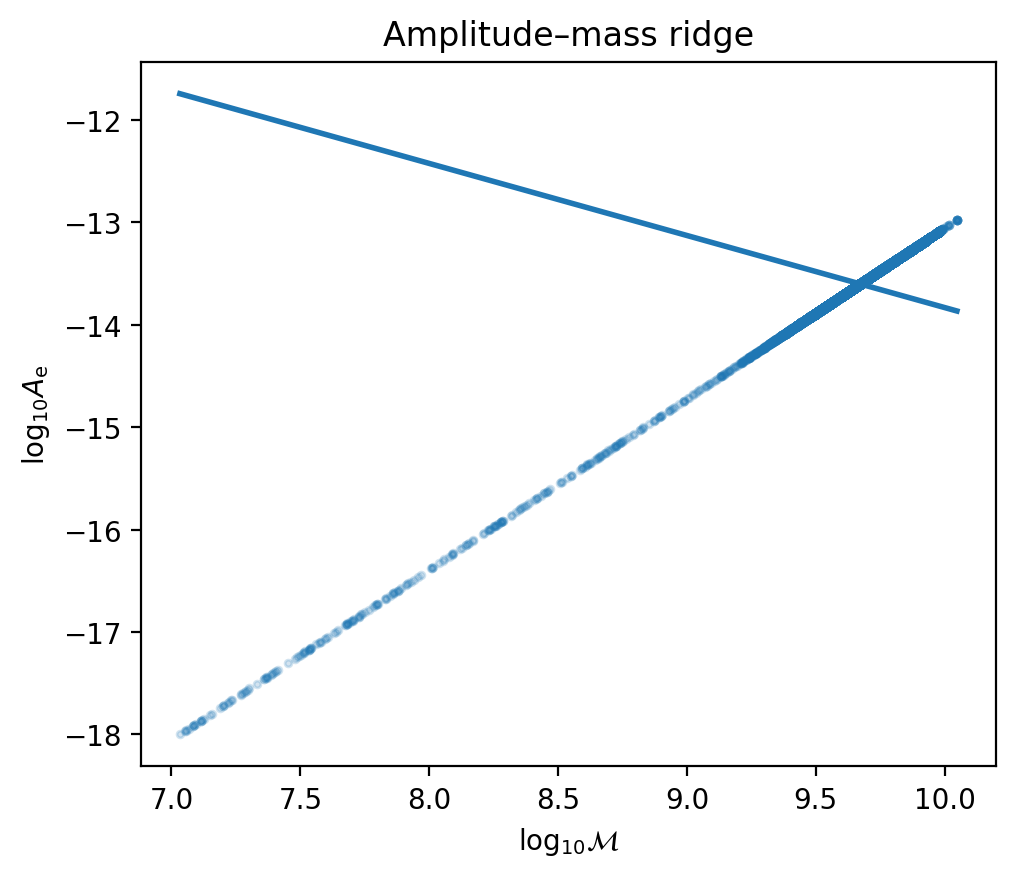

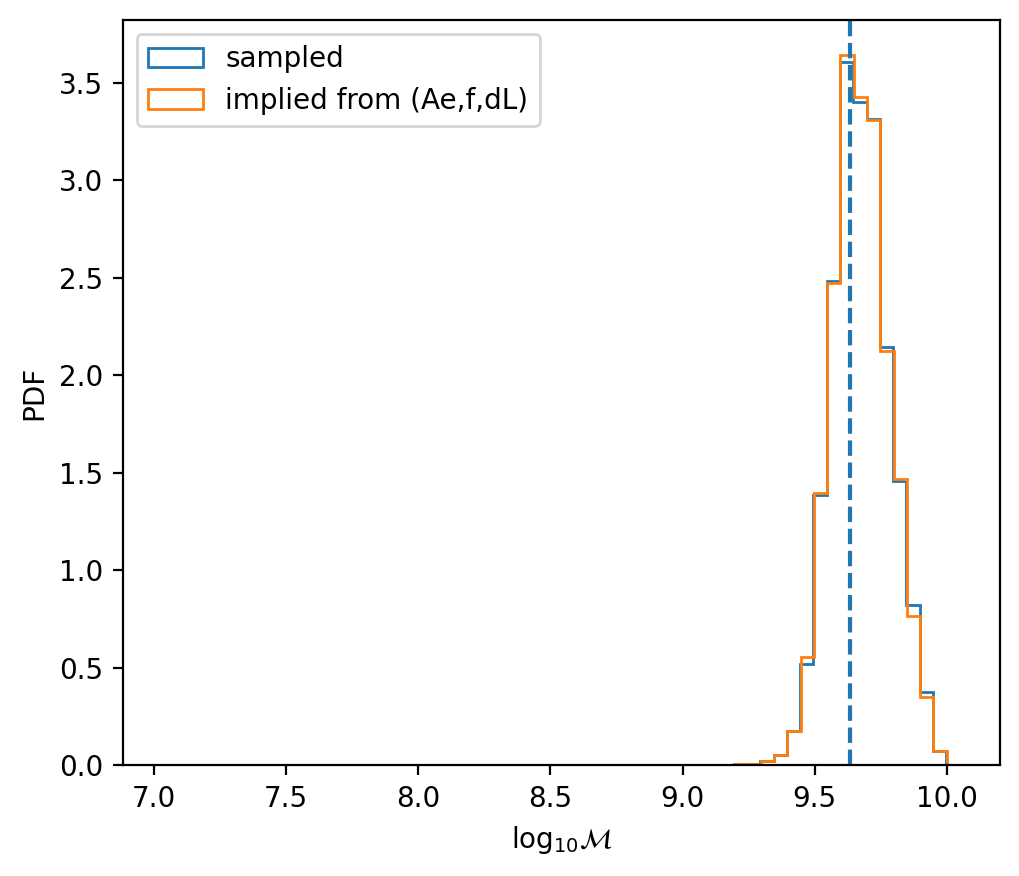

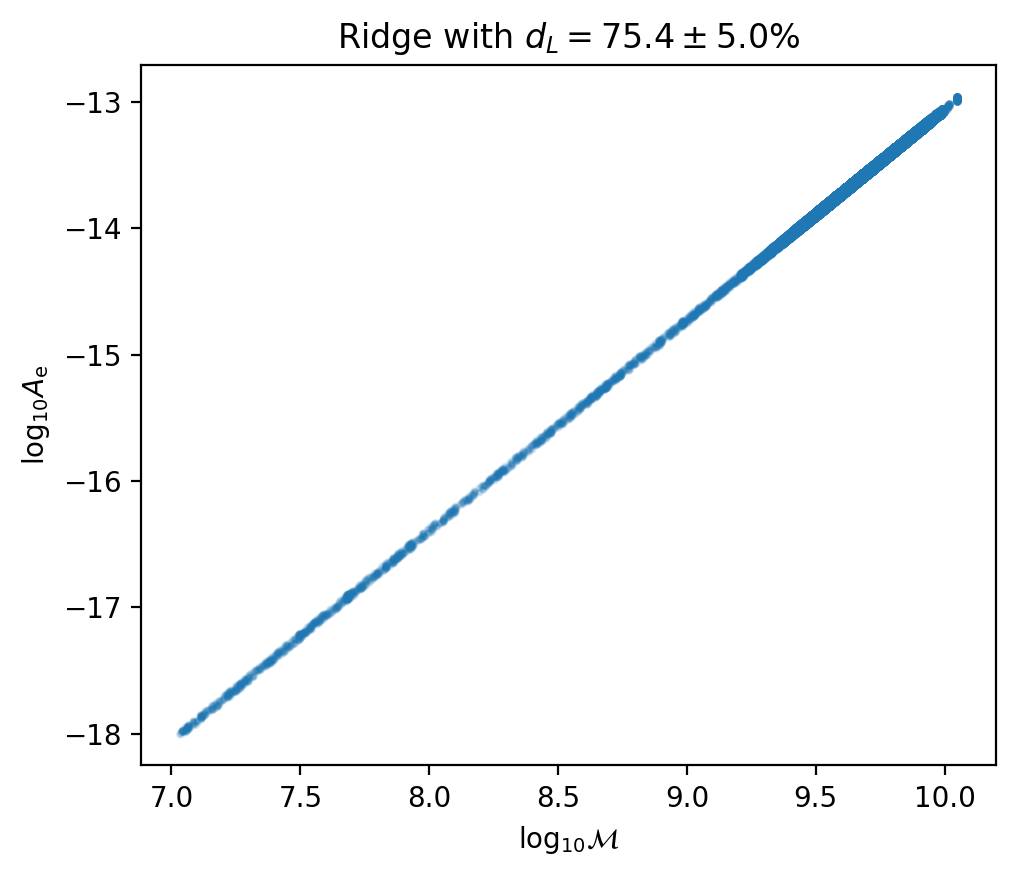

In [9]:
# ====== assumes you already loaded samples_cold, burnin, thin, d_L_mask, target_d_L, T_sun, megaparsec, speed_of_light ======

import numpy as np
import matplotlib.pyplot as plt

# pull arrays
S   = samples_cold[0][burnin::thin]
Ae  = 10.0**S[:,4]
f   = 10.0**S[:,3]
Mc  = 10.0**S[:,5]

# ---------------- 1) Ridge slope: log10(Ae) vs log10(Mc) ----------------
midx = d_L_mask
x = np.log10(Mc[midx])
y = np.log10(Ae[midx])

# robust polyfit (unweighted). If you want Theil–Sen, import from scipy.stats.
slope, intercept = np.polyfit(x, y, 1)
print(f"Ridge slope = {slope:.4f}  (expected ≈ 1.6667 = 5/3)")
print(f"Intercept   = {intercept:.4f}")

plt.figure(figsize=(5.2,4.5))
plt.scatter(x, y, s=6, alpha=0.20)
xg = np.linspace(x.min(), x.max(), 200)
plt.plot(xg, slope*xg + intercept, lw=2)
plt.xlabel(r'$\log_{10}\mathcal{M}$')
plt.ylabel(r'$\log_{10}A_{\rm e}$')
plt.title('Amplitude–mass ridge')
plt.tight_layout()

# ---------------- 2) Reconstruct M from (Ae,f,dL) ----------------
# M_imp = [ Ae * dL * (Mpc/c) / (2*(pi f)^(2/3)) ]^(3/5) / T_sun
Mpc_over_c = megaparsec / speed_of_light
Mc_imp = ((Ae * target_d_L * Mpc_over_c) / (2.0*(np.pi*f)**(2.0/3.0)))**(3.0/5.0) / T_sun

logMc     = np.log10(Mc[midx])
logMc_imp = np.log10(Mc_imp[midx])

def q16_50_84(a):
    return np.percentile(a, [16,50,84])

q_Mc     = q16_50_84(logMc)
q_Mc_imp = q16_50_84(logMc_imp)
print(f"log10 M (sampled):   median={q_Mc[1]:.5f}  -{q_Mc[1]-q_Mc[0]:.5f}/+{q_Mc[2]-q_Mc[1]:.5f}")
print(f"log10 M (implied):   median={q_Mc_imp[1]:.5f}  -{q_Mc_imp[1]-q_Mc_imp[0]:.5f}/+{q_Mc_imp[2]-q_Mc_imp[1]:.5f}")
print(f"Δ(log10 M) median (sampled - implied) = {np.median(logMc - logMc_imp):.5e}")

plt.figure(figsize=(5.2,4.5))
plt.hist(logMc, bins=60, histtype='step', density=True, label='sampled')
plt.hist(logMc_imp, bins=60, histtype='step', density=True, label='implied from (Ae,f,dL)')
plt.axvline(np.log10(4.3e9), ls='--')  # injected truth
plt.xlabel(r'$\log_{10}\mathcal{M}$')
plt.ylabel('PDF')
plt.legend()
plt.tight_layout()

# Optional: verify amplitude identity directly
Ae_pred = 2.0*(Mc*T_sun)**(5.0/3.0) * (np.pi*f)**(2.0/3.0) / (target_d_L * Mpc_over_c)
rel = (Ae - Ae_pred)/Ae_pred
print(f"Amplitude identity check: median relative error = {np.median(rel[midx]):.3e},  95% in [{np.percentile(rel[midx],2.5):.2e}, {np.percentile(rel[midx],97.5):.2e}]")

# ---------------- 3) Relax the dL mask to visualize the ridge ----------------
tol_pct = 5.0  # try 5–10%
dL = 2.0*(Mc*T_sun)**(5.0/3.0) * (np.pi*f)**(2.0/3.0) / Ae * (speed_of_light/megaparsec)
lo = target_d_L*(1 - tol_pct/100.0)
hi = target_d_L*(1 + tol_pct/100.0)
mask_relaxed = np.where((dL>=lo) & (dL<=hi))[0]
print(f"Relaxed mask {tol_pct:.1f}% keeps {mask_relaxed.size} samples.")

plt.figure(figsize=(5.2,4.5))
plt.scatter(np.log10(Mc[mask_relaxed]), np.log10(Ae[mask_relaxed]), s=4, alpha=0.15)
plt.xlabel(r'$\log_{10}\mathcal{M}$'); plt.ylabel(r'$\log_{10}A_{\rm e}$')
plt.title(fr'Ridge with $d_L={target_d_L}\pm{tol_pct}\%$')
plt.tight_layout()


In [10]:
# --- 0) Extract arrays (post burnin/thin) ---
burnin = 0
thin   = 1

logAe = samples_cold[0][burnin::thin, 4]          # log10 A_e
logf  = samples_cold[0][burnin::thin, 3]          # log10 f_gw
logMc = samples_cold[0][burnin::thin, 5]          # log10 M_chirp

# constants for identity checks (same as you used earlier)
import numpy as np, scipy.constants as sc
T_sun = sc.G*1.98855e30/sc.c**3                    # s
MPC2S = 3.085677581e22/sc.c                        # 1 Mpc / c in s
pi    = np.pi

# --- 1) dL from samples and a distance mask ---
# h = 10**logAe  (QuickCW stores log10 A_e)
h   = 10.0**logAe
f   = 10.0**logf
Mc  = 10.0**logMc

# distance implied by (A_e,f,Mc)  → eqn you already use
dL_from_samples = 2*(Mc*T_sun)**(5/3) * (pi*f)**(2/3) / h * sc.c / 3.085677581e22  # meters→Mpc
# mask around the target distance
tol_pct = 5.0
lo = target_d_L*(1 - tol_pct/100)
hi = target_d_L*(1 + tol_pct/100)
mask = (dL_from_samples >= lo) & (dL_from_samples <= hi)

print(f"Masked {mask.sum()} / {mask.size} samples with dL in [{lo:.2f},{hi:.2f}] Mpc")

# --- 2) Fit the ridge slope (y = a*x + b, x=log10 M, y=log10 A_e) ---
x = logMc[mask]
y = logAe[mask]
a, b = np.polyfit(x, y, 1)
print(f"Ridge slope = {a:.4f}  (expected +5/3 ≈ {5/3:.4f})")
print(f"Intercept   = {b:.4f}")

# --- 3) Compare sampled log10 M to the value implied by (A_e,f,dL=target) ---
# invert the amplitude relation for log10 M:
# log10 A_e = (5/3)log10 M + (2/3)log10 f + C - log10 dL
# ⇒ log10 M = (3/5)[log10 A_e - (2/3)log10 f - C + log10 dL]
C = np.log10(2*(T_sun**(5/3))*(pi**(2/3))*sc.c/3.085677581e22)  # constant in base-10
logMc_implied = (3/5)*(logAe - (2/3)*logf - C + np.log10(target_d_L))

def q16_50_84(z):
    q16,q50,q84 = np.percentile(z, [16,50,84])
    return q50, q50-q16, q84-q50

m50, mlo, mhi = q16_50_84(logMc[mask])
mi50, milo, mihi = q16_50_84(logMc_implied[mask])
print(f"log10 M (sampled):   median={m50:.5f}  -{mlo:.5f}/+{mhi:.5f}")
print(f"log10 M (implied):   median={mi50:.5f} -{milo:.5f}/+{mihi:.5f}")
print(f"Δ(log10 M) median (sampled - implied) = {(m50-mi50):.5e}")

# amplitude identity cross-check (rebuild A_e from M_implied and f, dL)
A_recon = 2*( (10**logMc_implied[mask])*T_sun )**(5/3) * (pi*(10**logf[mask]))**(2/3) / target_d_L * sc.c / 3.085677581e22
rel_err = (A_recon - (10**logAe[mask]))/(10**logAe[mask])
q16,q50,q84 = np.percentile(rel_err, [2.5,50,97.5])
print(f"Amplitude identity check: median rel. error = {q50:.3e},  95% in [{q16:.2e}, {q84:.2e}]")


Masked 632525 / 100000000 samples with dL in [71.63,79.17] Mpc


/usr/local/anaconda/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3378: RankWarning: Polyfit may be poorly conditioned
  exec(code_obj, self.user_global_ns, self.user_ns)


Ridge slope = -0.7031  (expected +5/3 ≈ 1.6667)
Intercept   = -6.8009
log10 M (sampled):   median=9.66975  -0.10406/+0.12078
log10 M (implied):   median=9.66984 -0.10313/+0.11928
Δ(log10 M) median (sampled - implied) = -9.72748e-05
Amplitude identity check: median rel. error = 7.710e-07,  95% in [-2.02e-06, 3.22e-06]


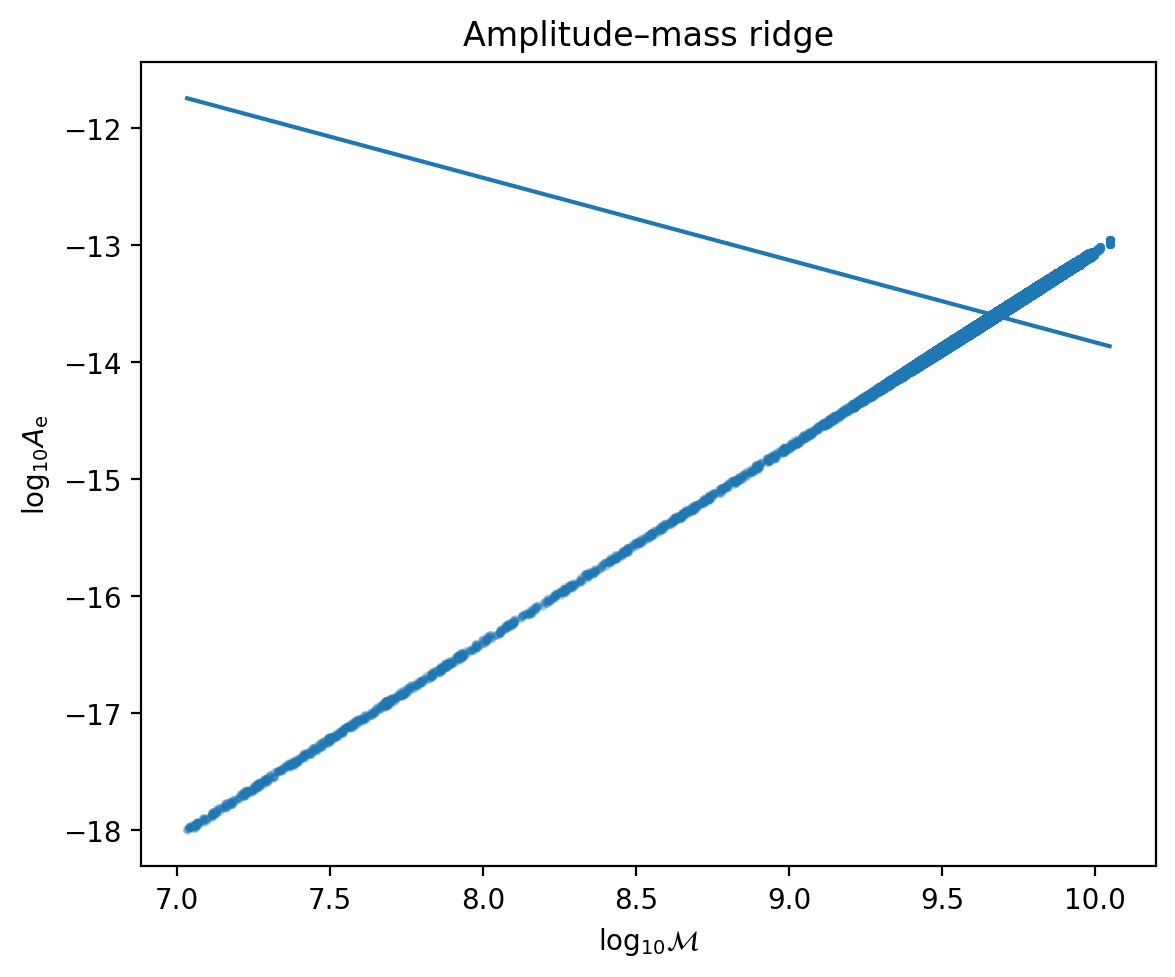

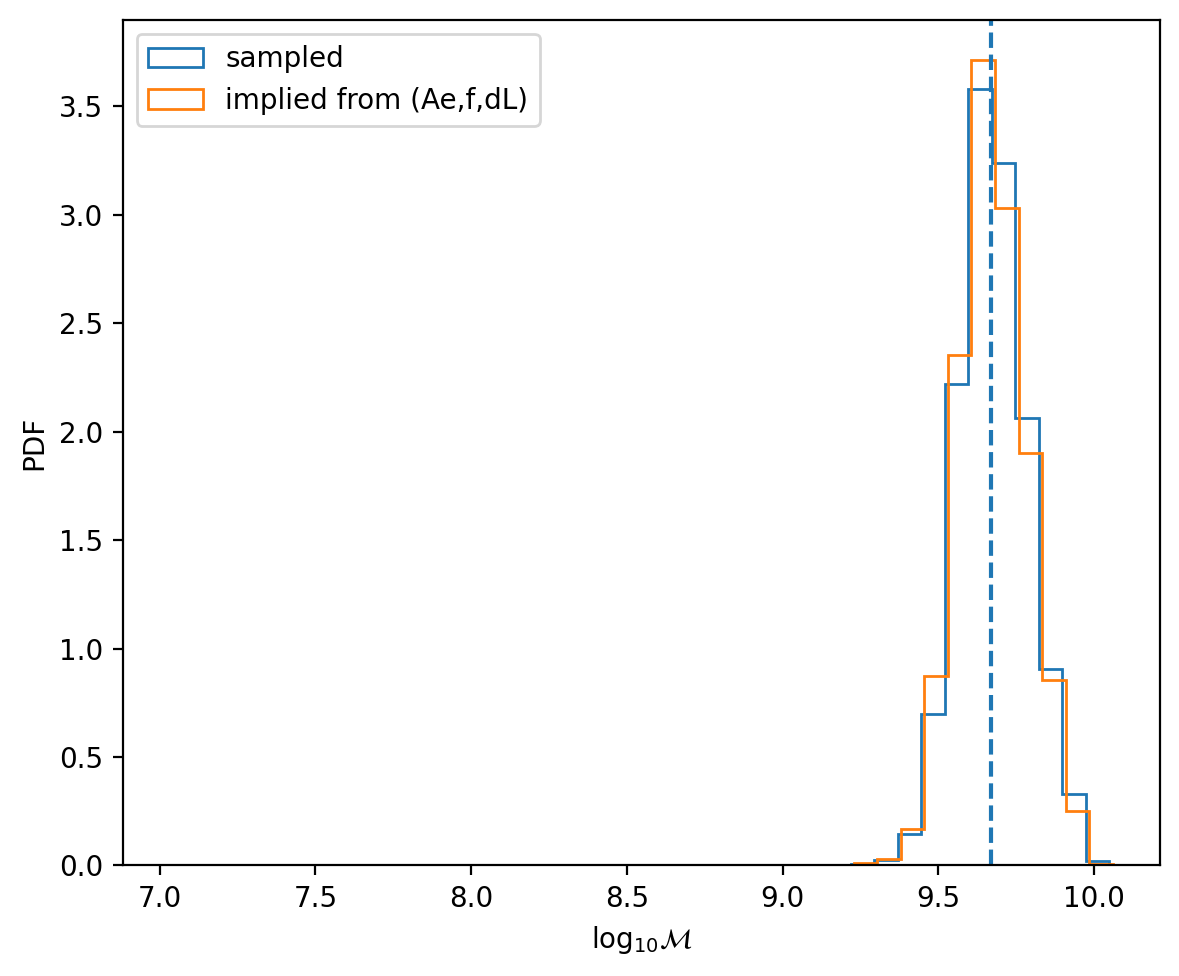

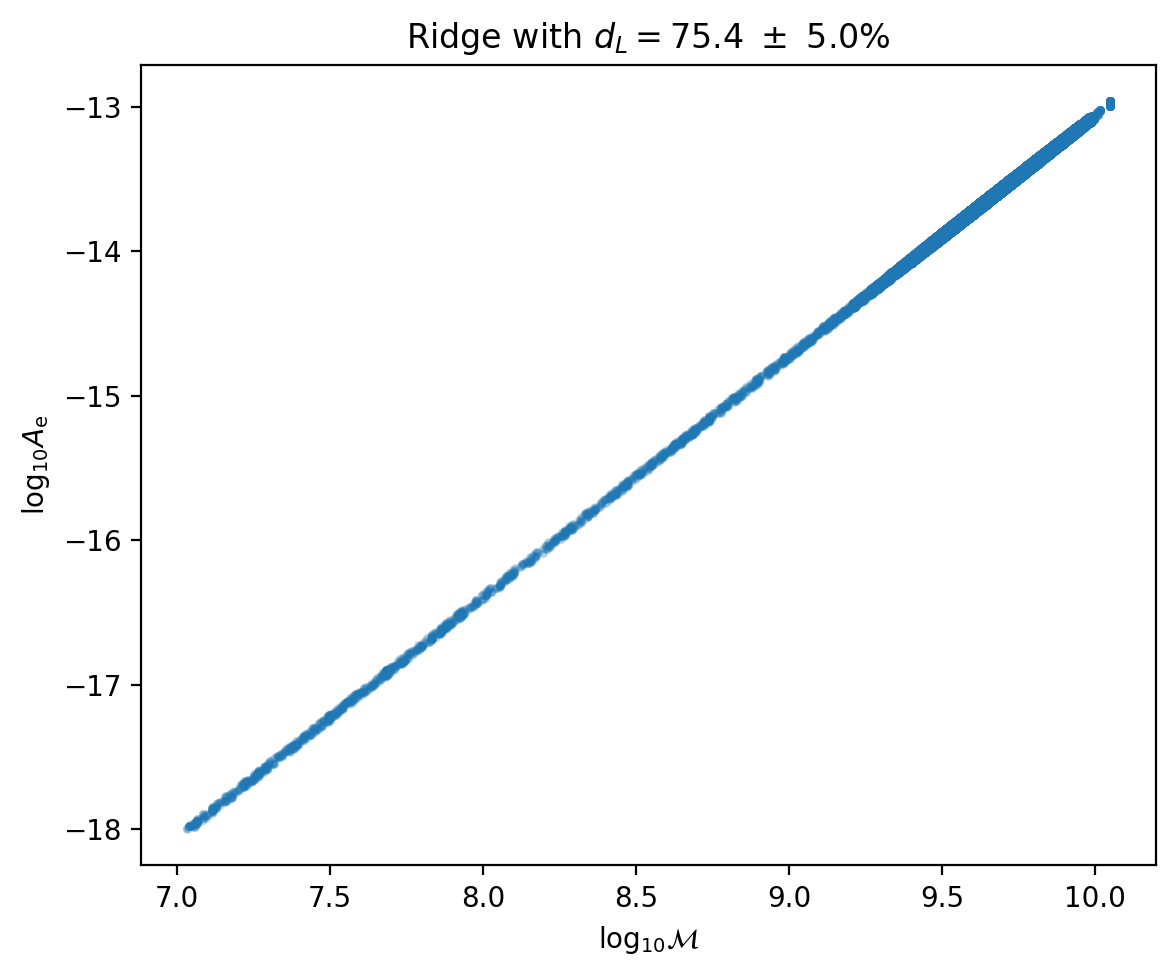

In [11]:
# --- 4) Plots: ridge, mass PDFs, ridge with mask ---
import matplotlib.pyplot as plt

# ridge scatter + best-fit line
plt.figure(figsize=(6,5))
plt.scatter(x, y, s=5, alpha=0.25)
xs = np.linspace(x.min(), x.max(), 100)
plt.plot(xs, a*xs + b)
plt.title("Amplitude–mass ridge")
plt.xlabel(r"$\log_{10}\mathcal{M}$")
plt.ylabel(r"$\log_{10}A_{\rm e}$")
plt.tight_layout()

# sampled vs implied mass PDFs
plt.figure(figsize=(6,5))
plt.hist(logMc[mask], bins=40, density=True, histtype="step", label="sampled")
plt.hist(logMc_implied[mask], bins=40, density=True, histtype="step", label="implied from (Ae,f,dL)")
plt.axvline(m50, linestyle="--")
plt.legend()
plt.xlabel(r"$\log_{10}\mathcal{M}$")
plt.ylabel("PDF")
plt.tight_layout()

# ridge with masked samples only
plt.figure(figsize=(6,5))
plt.scatter(logMc[mask], logAe[mask], s=5, alpha=0.25)
plt.title(rf"Ridge with $d_L={target_d_L}\ \pm\ {tol_pct:.1f}\%$")
plt.xlabel(r"$\log_{10}\mathcal{M}$")
plt.ylabel(r"$\log_{10}A_{\rm e}$")
plt.tight_layout()


hamp [6.2618183e-12 8.7369629e-18 9.8359422e-15 ... 2.9562832e-14 2.9562832e-14
 2.9562832e-14]
freq [3.7000025e-09 3.7000025e-09 3.7000025e-09 ... 3.7000025e-09 3.7000025e-09
 3.7000025e-09]
mc [1.1089887e+07 4.0102052e+10 1.1089887e+07 ... 2.9482121e+10 2.9482121e+10
 2.9482121e+10]
Length of logdL 100000000
required values 8.484214 3.7000025e-09 108456936.0 3.9389356e-14
dL min 74.646
dL max 76.15400000000001
10**log10_d_L [1.2520342e-05 7.6446065e+06 7.9707820e-03 ... 1.3529763e+03 1.3529763e+03
 1.3529763e+03]
min 10**log10_d_L 1.2520342e-05
max 10**log10_d_L 304939620.0
d_L_mask [   26110    26111    26112 ... 99849743 99957396 99957397]
notd_L_mask1 [       0        2        3 ... 99999825 99999834 99999862]
notd_L_mask2 [       1        4        5 ... 99999997 99999998 99999999]
merged_non_dL [       0        2        3 ... 99999997 99999998 99999999]
Sample shape (100000000, 9)
dL_mask length 126372
9


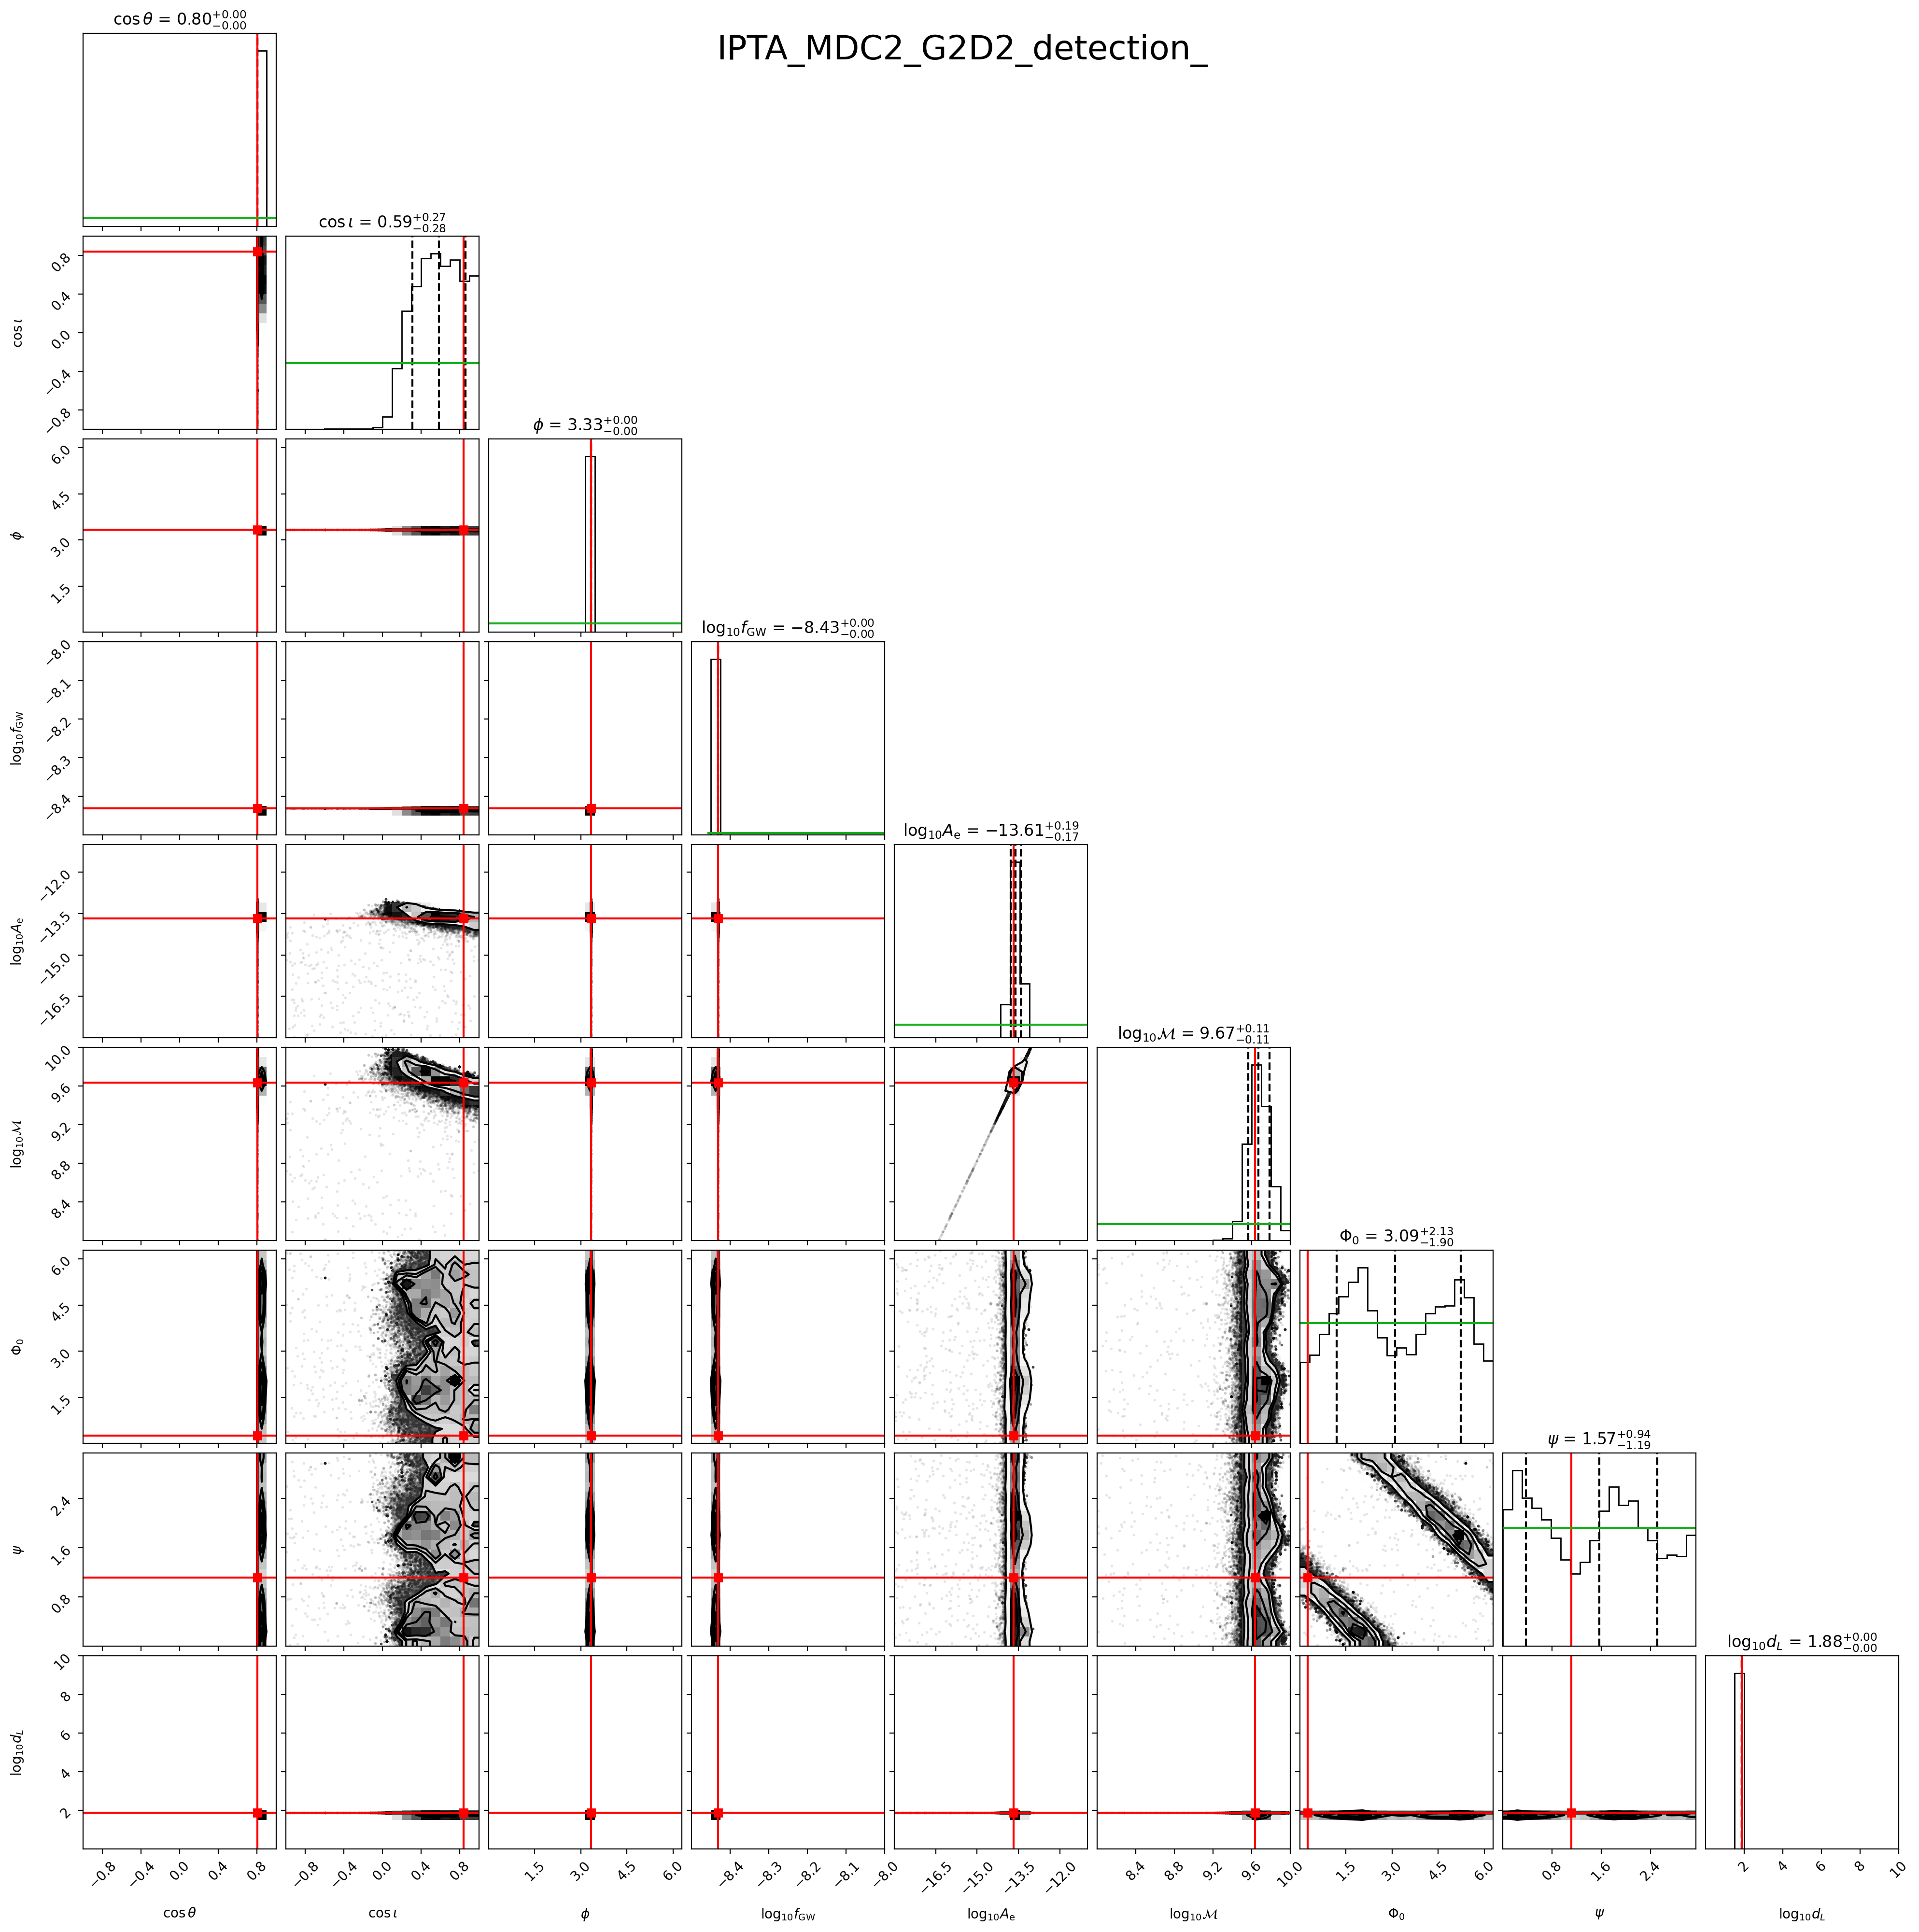

In [12]:
#corner plot of parameters common to all pulsars (Contains Luminosity distance)
corner_mask = [0, 1, 2, 3, 4, 5, 6, 7]
par_keys = ["0_cos_gwtheta", "0_cos_inc", "0_gwphi", "0_log10_fgw",
          "0_log10_h", "0_log10_mc", "0_phase0", "0_psi","log10_d_L"]
labels = [r"$\cos \theta$", r"$\cos \iota$", r"$\phi$", r"$\log_{10} f_{\rm GW}$",
          r"$\log_{10} A_{\rm e}$", r"$\log_{10} {\cal M}$", r"$\Phi_0$", r"$\psi$",r"$\log_{10} d_L$"]
          
# Mapping from pretty labels → xxx0 keys
label_to_key = {
    r"$\cos \theta$": "0_cos_gwtheta",
    r"$\cos \iota$": "0_cos_inc",
    r"$\phi$": "0_gwphi",
    r"$\log_{10} f_{\rm GW}$": "0_log10_fgw",
    r"$\log_{10} A_{\rm e}$": "0_log10_h",
    r"$\log_{10} {\cal M}$": "0_log10_mc",
    r"$\Phi_0$": "phase0",
    r"$\psi$": "psi",
    r"$\log_{10} d_L$": "distance"
}

# Build truths list (log-transform distance for d_L)
truths = []
for lab in labels:
    key = label_to_key[lab]
    if lab == r"$\log_{10} d_L$":
        truths.append(np.log10(xxx0[key]))
    else:
        truths.append(xxx0[key])
        
#set burnin and thinning
#burnin = 0
#burnin = 500_000
burnin = 0#int(1e6)
thin = 1

#set ranges
ranges = [(-1,1), (-1,1), (0,2*np.pi), (-8.5,-8), (-18,-11), (8,10), (0,2*np.pi), (0,np.pi), (0,10)]
#ranges = [0.99]*9


megaparsec = 3.086e+22 #meter
speed_of_light = 299792458.0 #m/s
T_sun = 1.327124400e20 / speed_of_light**3 #G*M_sun/c^3 = R_sun/c-->Sun time

############################################################################
h_amp = 10**samples_cold[0][burnin::thin,4]
fff = 10**samples_cold[0][burnin::thin,3]
mmm = 10**samples_cold[0][burnin::thin,5]

print('hamp',h_amp)
print('freq',fff)
print('mc',mmm)

log10_d_L = np.log10(2 * (mmm*T_sun)**(5/3) * (np.pi*fff)**(2/3) / h_amp *speed_of_light/megaparsec)
print("Length of logdL", len(log10_d_L))
print("required values",np.max(log10_d_L), fff[1000], mmm[1000], h_amp[1000] )
#####################################
target_d_L = 75.4#Mpc
d_L_percent_tolerance = 1.0
#####################################

d_L_min = target_d_L*(1-d_L_percent_tolerance/100)
d_L_max = target_d_L*(1+d_L_percent_tolerance/100)
print("dL min",d_L_min)
print("dL max",d_L_max)
print("10**log10_d_L",10**log10_d_L)
print("min 10**log10_d_L",np.min(10**log10_d_L))
print("max 10**log10_d_L",np.max(10**log10_d_L))

d_L_mask = np.where((10**log10_d_L>=d_L_min) & (10**log10_d_L<=d_L_max))[0]
print("d_L_mask",d_L_mask)

#########################
not_d_L_mask_1 = np.where((10**log10_d_L<d_L_min))[0] #& (10**log10_d_L>d_L_max))[0]
print("notd_L_mask1",not_d_L_mask_1)
not_d_L_mask_2 = np.where((10**log10_d_L>d_L_max))[0] #& ())[0]
print("notd_L_mask2",not_d_L_mask_2)

merged_non_dL = np.concatenate((not_d_L_mask_1,not_d_L_mask_2))
print("merged_non_dL",merged_non_dL)
########################################

samples2plot = np.concatenate((samples_cold[0][burnin::thin,corner_mask], np.array([log10_d_L,]).T), axis=1)

print("Sample shape", samples2plot.shape)
print("dL_mask length", len(d_L_mask))
print(len(ranges))

#fig = corner.corner(samples2plot[d_L_mask, :],
 #                   labels=labels,
  #                  show_titles=True, quantiles=[0.16, 0.5, 0.84],
   #                 range=ranges, hist_kwargs={"density":True})

fig = corner.corner(
    samples2plot[d_L_mask, :],   # <-- use samples2plot, not samples2plot_detect
    labels=labels,
    show_titles=True,
    quantiles=[0.16, 0.5, 0.84],
    range=ranges,
    hist_kwargs={"density": True},
    truths=truths,
    truth_color="red"
)

#plot priors over 1D posteriors
for i, ax in enumerate(fig.axes):
    if i==0 or i==(len(labels)+1): #cos inc and cos theta
        Xs = np.linspace(-1,1)
        ax.plot(Xs, Xs*0+1/2, color="xkcd:green")
    elif i==2*(len(labels)+1) or i==6*(len(labels)+1): #gwphi and phase0
        Xs = np.linspace(0,2*np.pi)
        ax.plot(Xs, Xs*0+1/(2*np.pi), color="xkcd:green")
    elif i==3*(len(labels)+1): #log10_fgw
        Xs = np.linspace(np.log10(3.5e-9), -7.0)
        # Y = plot_Gaussian(Xs,np.log10(1.13e-8),1)
        # ax.plot(Xs,Y, color='xkcd:green')
        ax.plot(Xs, Xs*0+1/(np.log10(3e-7)+8.704), color="xkcd:green")
    elif i==4*(len(labels)+1): #log10_A
        Xs = np.linspace(-18, -11)
        ax.plot(Xs, Xs*0+1/7, color="xkcd:green")
    elif i==5*(len(labels)+1): #log10_M_ch
        Xs = np.linspace(7.84, 10.26)
        # Y=plot_Gaussian(Xs,9.86,1)
        # ax.plot(Xs,Y, color='xkcd:green')
        ax.plot(Xs, Xs*0+1/3, color="xkcd:green")
    elif i==7*(len(labels)+1): #psi
        Xs = np.linspace(0,np.pi)
        ax.plot(Xs, Xs*0+1/np.pi, color="xkcd:green")
        
fig.suptitle(crnr_plt_title2, fontsize = 25);

## Trace Plots

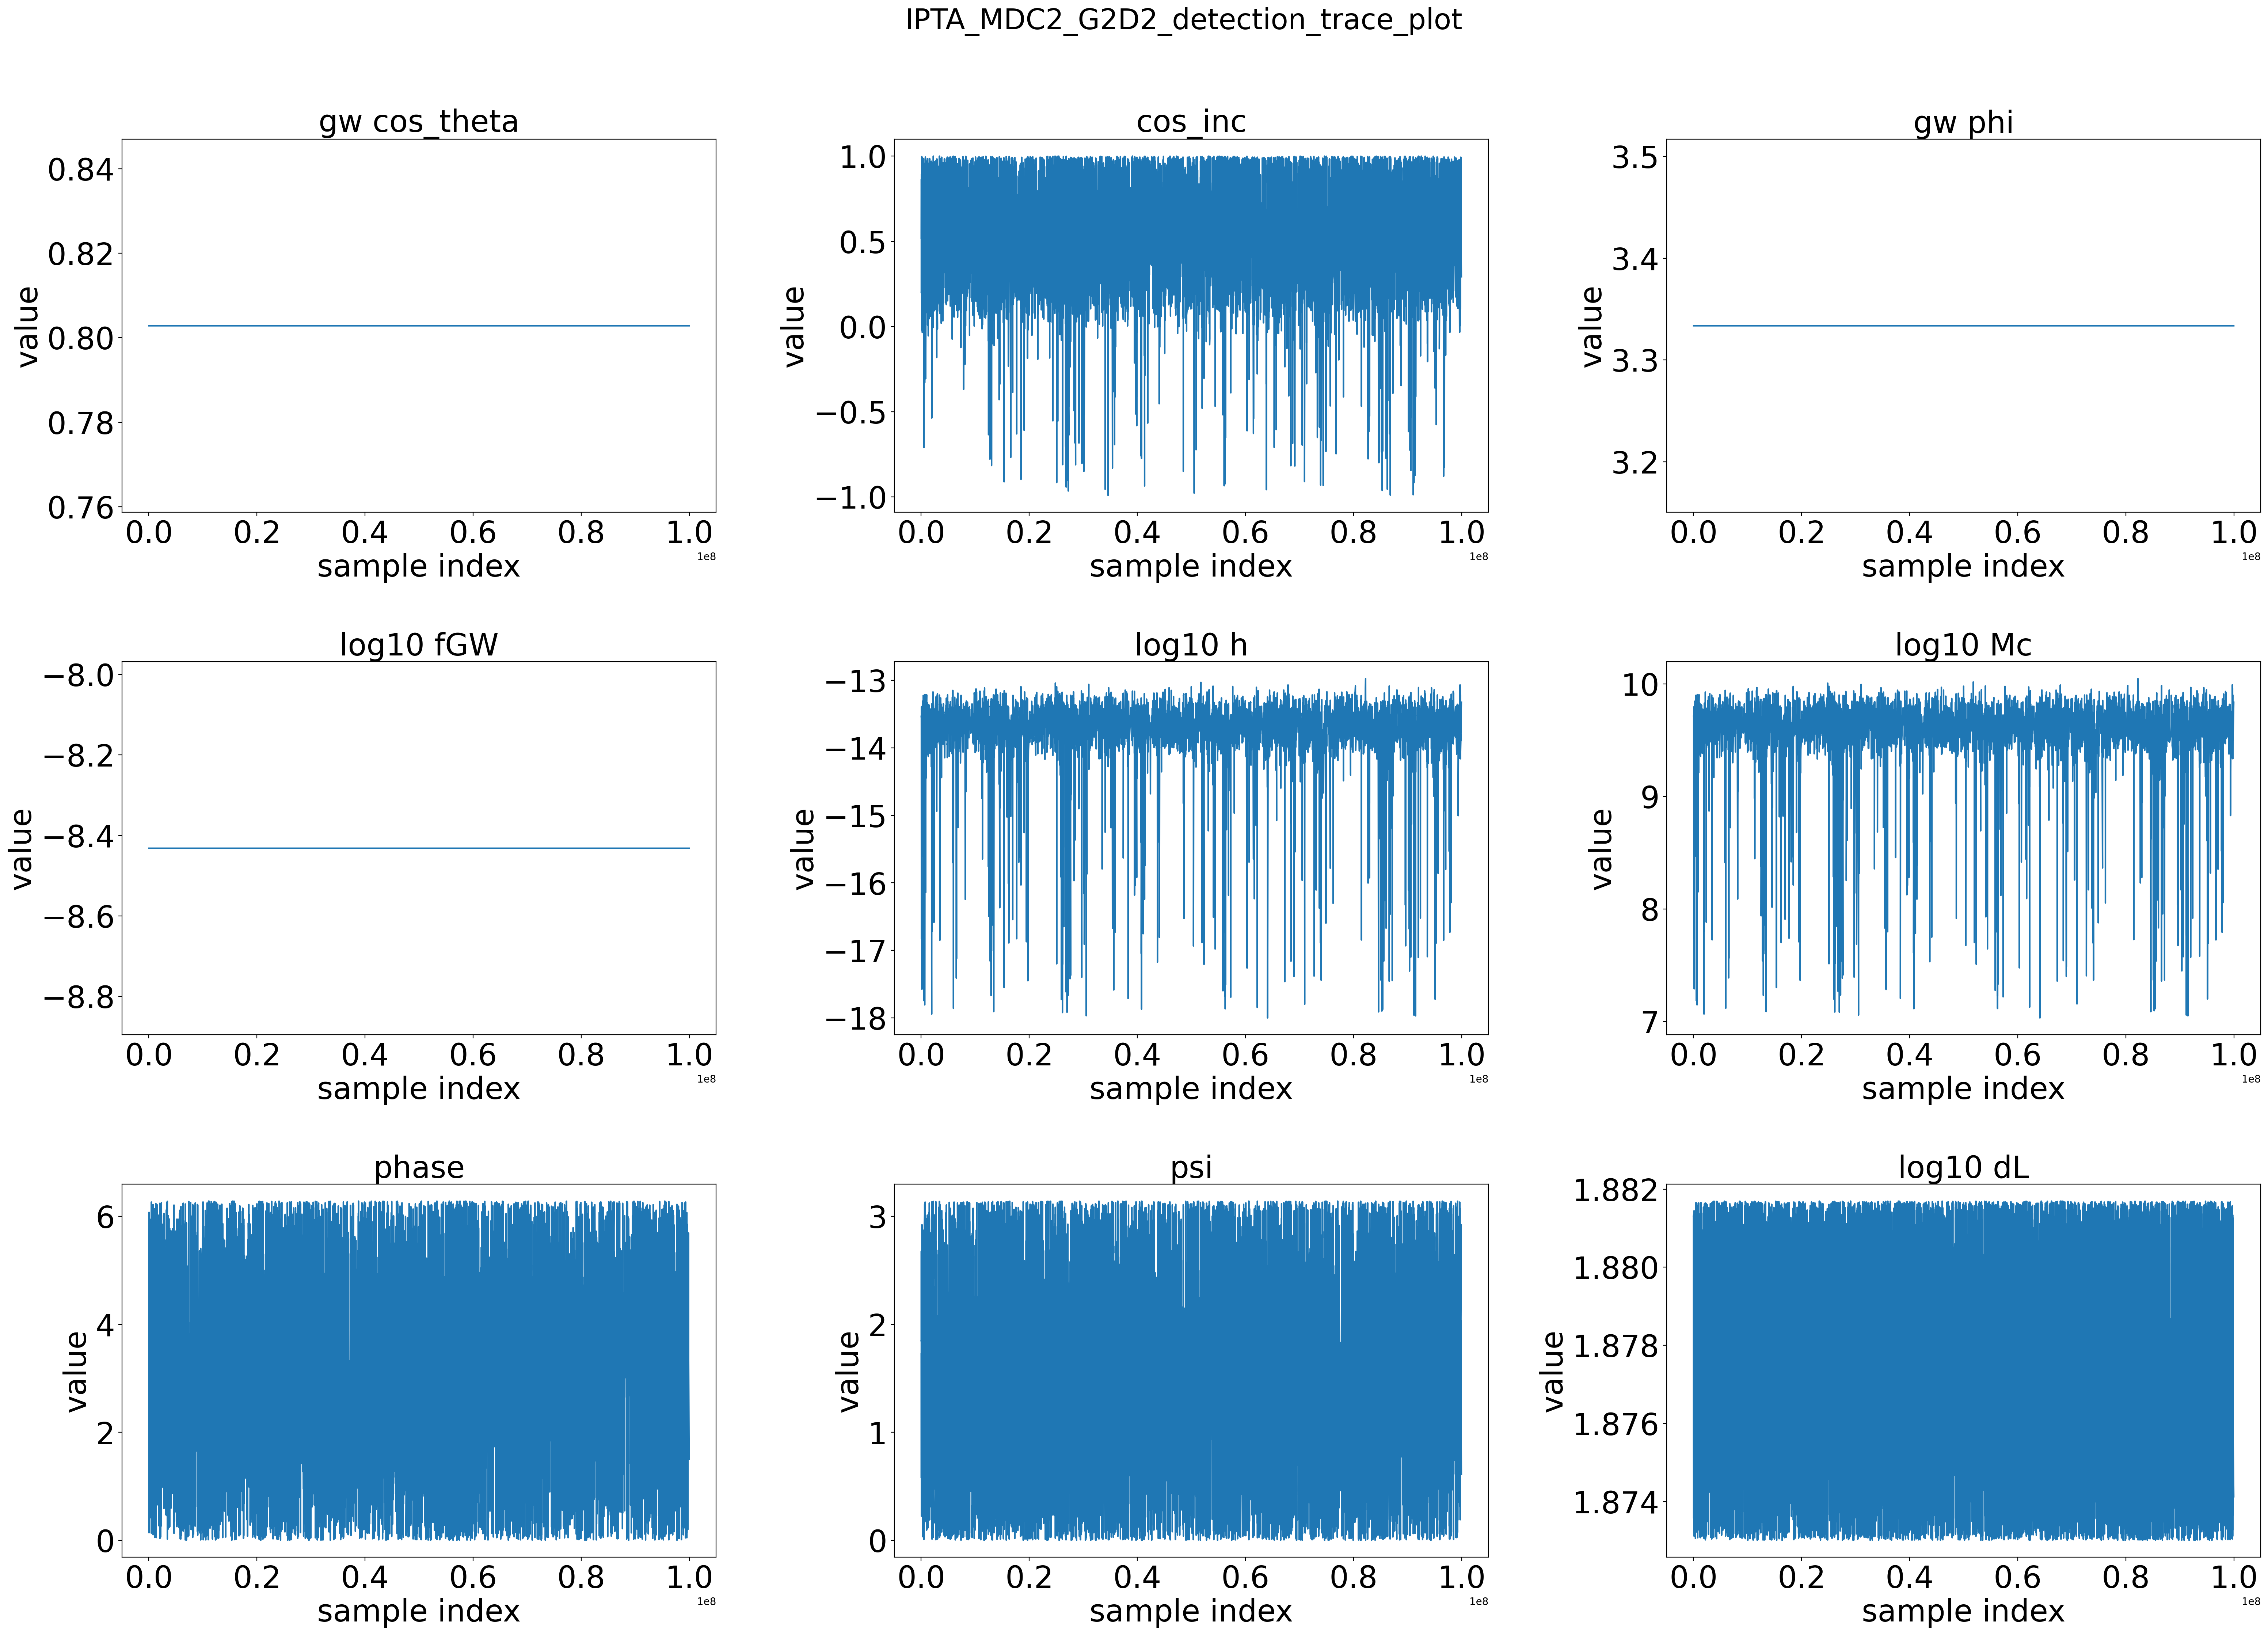

In [13]:
import matplotlib.pyplot as plt

title = ["gw cos_theta", "cos_inc", "gw phi", "log10 fGW", 
         "log10 h", "log10 Mc", "phase", "psi", "log10 dL"]

j = -1
row, column = 3, 3
fig, axs = plt.subplots(row, column, figsize=(30, 20))
fig.tight_layout(h_pad=3, w_pad=2)

# Loop over parameters
for i in range(len(title)): 
    if i % column == 0:
        j += 1
    axs[j, i % column].plot(d_L_mask, samples2plot[d_L_mask, i])
    axs[j, i % column].set_title(title[i], fontsize=30)    # bigger subplot title
    axs[j, i % column].tick_params(axis="both", labelsize=30)  # bigger tick labels
    axs[j, i % column].set_xlabel("sample index", fontsize=30)
    axs[j, i % column].set_ylabel("value", fontsize=30)

# Global title
fig.suptitle(trace_plot_title, fontsize=28, y=1.08)

plt.subplots_adjust(hspace=0.4, wspace=0.3)  # more spacing
#plt.show()
#plt.savefig("trace_plots.png", dpi=200, bbox_inches="tight")


In [14]:
print(np.min(samples2plot[d_L_mask,5]))
print(np.max(np.log10(samples2plot[d_L_mask,5])))

7.032679e+00
1.0020826


## SD BF

hmin -17.999344
hmax -12.975309
Mc min 7.032679
Mc max 10.04807
126372


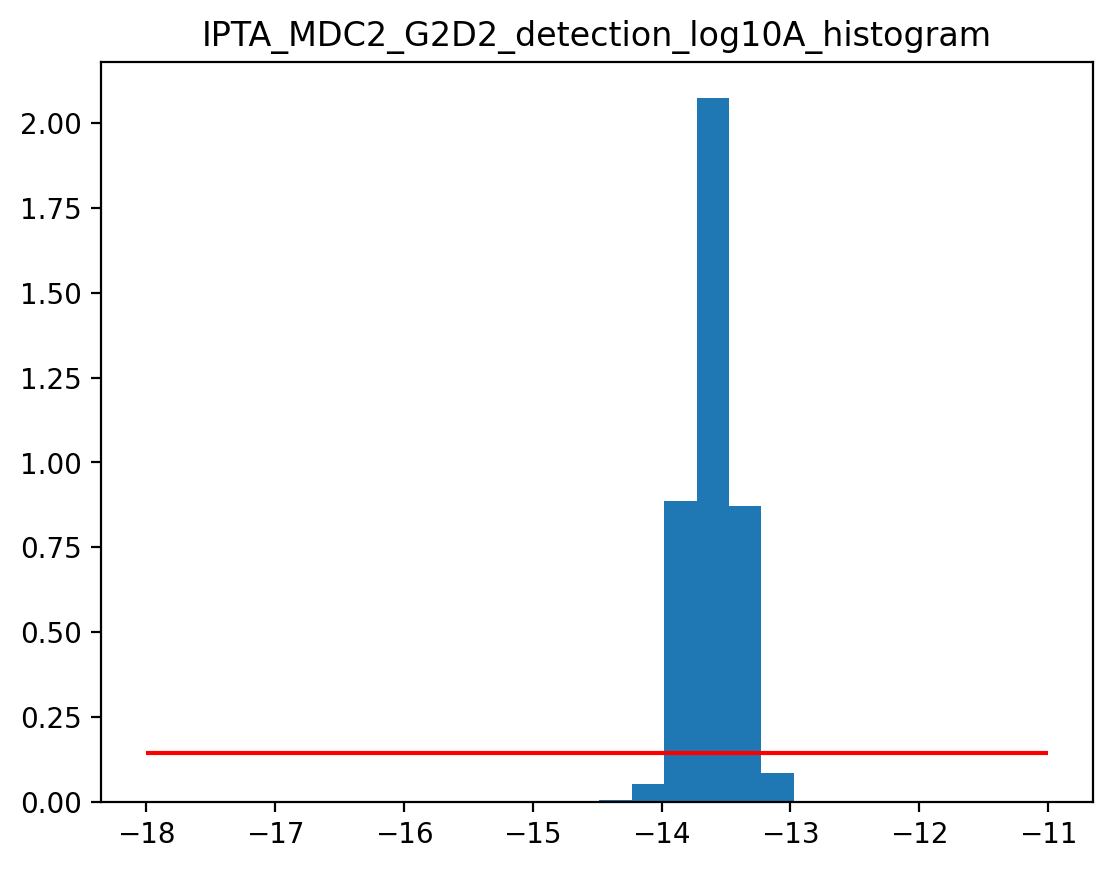

In [15]:
logAmin_dL = np.min(samples2plot[d_L_mask,4])
logAmax_dL = np.max(samples2plot[d_L_mask,4])
print("hmin",logAmin_dL)
print("hmax",logAmax_dL)
print("Mc min",np.min(samples2plot[d_L_mask,5]))
print("Mc max",np.max(samples2plot[d_L_mask,5]))

print(len(samples2plot[d_L_mask,4]))

plt.hist(samples2plot[d_L_mask,4], bins=20, density=True)
plt.hlines(1/(-11 - logAmin_dL), logAmin_dL, -11,  color='red')
plt.title(BF_histogram_title)
plt.show()

/usr/local/anaconda/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3440: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/anaconda/lib/python3.9/site-packages/numpy/core/_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/usr/local/anaconda/lib/python3.9/site-packages/numpy/core/_methods.py:262: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/anaconda/lib/python3.9/site-packages/numpy/core/_methods.py:222: RuntimeWarning: invalid value encountered in true_divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/usr/local/anaconda/lib/python3.9/site-packages/numpy/core/_methods.py:254: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


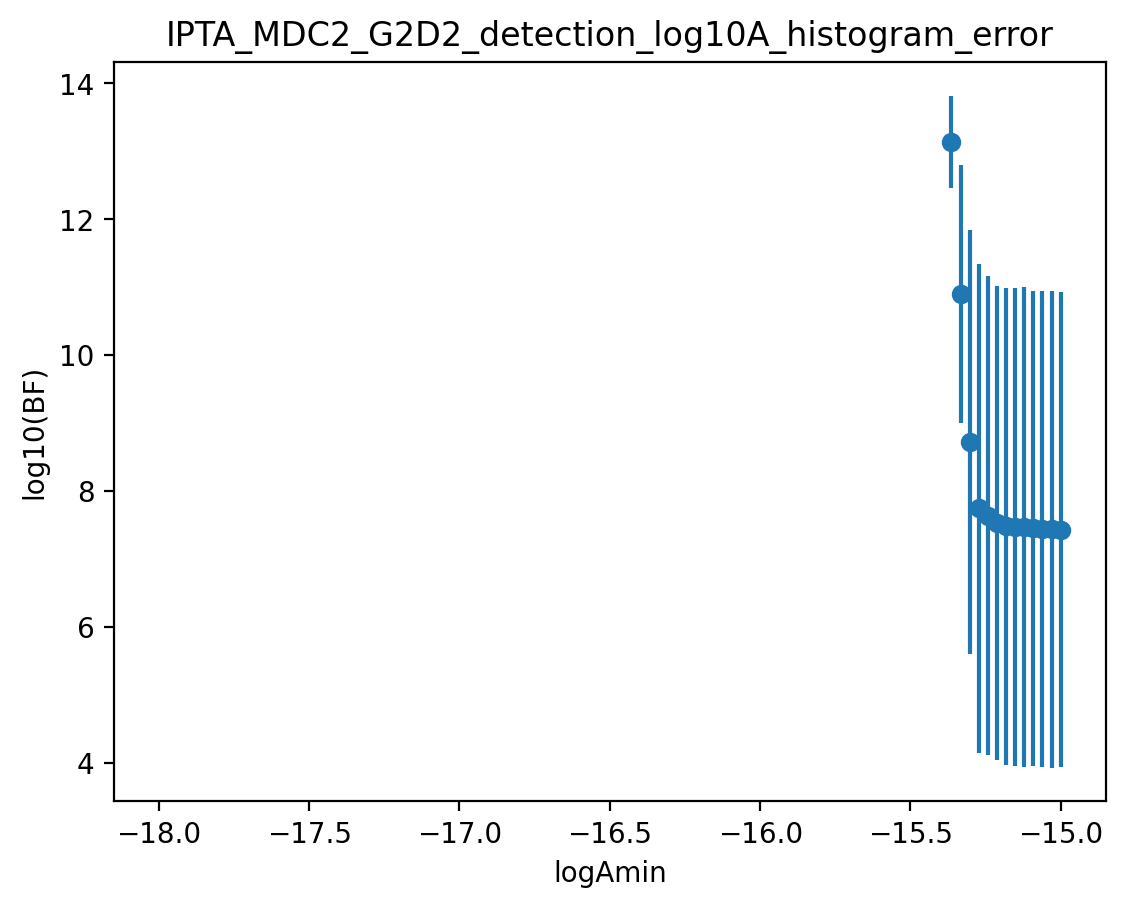

In [16]:
#d_L correlated SD BF
logamins = np.linspace(logAmin_dL, -15, 100)
BF_arr = []
BF_err_arr = []

from enterprise_extensions import model_utils
for logamin in logamins:
    BF,BF_err = model_utils.bayes_fac(samples = samples2plot[d_L_mask,4], logAmin=logamin, logAmax=-11)
    BF_arr.append(BF)
    BF_err_arr.append(BF_err)

plt.errorbar(logamins, BF_arr, yerr=BF_err_arr, fmt='o')
plt.xlabel('logAmin')
plt.ylabel("log10(BF)")
plt.title(BFerr_title)
plt.show()

In [17]:
#d_L correlated SD BF
BF, BF_err = model_utils.bayes_fac(samples=samples2plot[d_L_mask,4], logAmax=-11)
print(f"log10A BF = {BF:.4f} ± {BF_err:.4f}")

log10A BF = nan ± nan


/usr/local/anaconda/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3440: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/anaconda/lib/python3.9/site-packages/numpy/core/_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/usr/local/anaconda/lib/python3.9/site-packages/numpy/core/_methods.py:262: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/anaconda/lib/python3.9/site-packages/numpy/core/_methods.py:222: RuntimeWarning: invalid value encountered in true_divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/usr/local/anaconda/lib/python3.9/site-packages/numpy/core/_methods.py:254: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


In [18]:
#Non d_L correlated SD BF
from enterprise_extensions import model_utils
BF,BF_err = model_utils.bayes_fac(samples = samples_cold[0][::10,4], logAmax=-11)
print(f"log10A BF = {BF:.4f} ± {BF_err:.4f}")

log10A BF = 209.4529 ± 3.5302


In [19]:
print(BF_arr[0:10])

[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]


In [20]:
print(BF_err_arr[0:10])

[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]
